In [21]:
%load_ext autoreload
%autoreload 2

import os
import sys
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from torch import nn
import torch.nn.functional as F

# Ensure project root on sys.path for local imports when running directly
try:
    HERE = os.path.dirname(os.path.abspath(__file__))  # type: ignore[name-defined]
except NameError:
    HERE = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# Add notebooks directory to sys.path for local imports
NOTEBOOKS_DIR = os.path.join(HERE, "notebooks")
if NOTEBOOKS_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOKS_DIR)

from train_dist_encoder import train, save_encoder, load_encoder
from cls.vectorhash.assoc_utils_np_2D import gen_gbook_2d, path_integration_Wgg_2d, module_wise_NN_2d
from cls.utils.GridUtils import *
from cls.hopfield import Hopfield

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
lambdas = [11,12,13]
Ng = np.sum(np.square(lambdas))
Npos = np.prod(lambdas)
# Npos = 300
gbook = gen_gbook_2d(lambdas, Ng, Npos)
Phi_np = smooth_gbook(gbook, lambdas, 0.25)
Phi = torch.tensor(Phi_np, dtype=torch.float32)

In [39]:
# encoder, config = load_encoder("/home/jackking/cls/encoders/goated_cnn_encoder.pt")
encoder, config = load_encoder("/home/jackking/cls/encoders/binary_20260409_083227/encoder_final.pt")
# encoder, ckpt = load_encoder("/home/jackking/cls/encoders/binary_20260420_183304/encoder_best.pt")

In [ ]:
cka_topk = 10
mod_loss_lambda = 0.5
out_dim = 256
encoder, config = load_encoder(f"encoder_cka_topk={cka_topk}_mod_loss_lambda={mod_loss_lambda}_out_dim={out_dim}.pt")

In [5]:
config

{'model_params': {'lambdas': [11, 12, 13],
  'hidden_dim': 1024,
  'hidden_channels': 128,
  'num_layers': 3,
  'out_dim': 256,
  'num_hidden_layers': 4,
  'kernel_size': 5,
  'nonlinearity': 'gelu',
  'output_nonlinearity': 'tanh',
  'gain': 5,
  'Npos': 50,
  'Nenv': 200,
  'encoder_type': 'mlp',
  'input_type': 'smoothed'}}

In [40]:
gain = config["model_params"]["gain"]
embed_dim = config["model_params"]["out_dim"]

code_dim, H, W = Phi.shape
Phi_flat = Phi.reshape(code_dim, H*W).T.to(device)
batch_size = 1000  # adjust as needed according to GPU/CPU RAM constraints
encoded_Phi_chunks = []
with torch.no_grad():
    for i in range(0, Phi_flat.shape[0], batch_size):
        encoded_chunk = encoder(Phi_flat[i:i+batch_size], gain=gain).detach().cpu()
        encoded_Phi_chunks.append(encoded_chunk)
encoded_Phi = torch.cat(encoded_Phi_chunks, dim=0)
encoded_Phi = encoded_Phi.reshape(Npos, Npos, embed_dim).to("cpu")

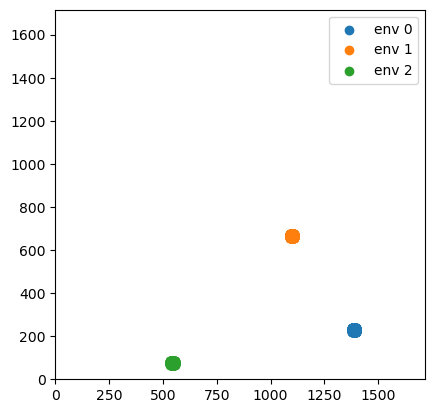

In [41]:
n_envs = 3
size = 20

used = []  # store placed (x, y)
C_pairs = []
max_tries = 10_000  # guard against infinite loops
touch_ok = False      # set False to forbid touching
tries = 0
while len(C_pairs) < n_envs and tries < max_tries:
    x = np.random.randint(0, Npos - size + 1)
    y = np.random.randint(0, Npos - size + 1)
    if all(not overlaps(x, y, px, py, size, touch_ok) for (px, py) in used):
        used.append((x, y))
        C_pairs.append((x, y))
    tries += 1

all_env_indices = []
goal_states = []
goal_locations = []

for env_idx in range(n_envs):
    C_X, C_Y = C_pairs[env_idx]
    x, y = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
    env_indices = np.stack((C_X + x, C_Y + y), axis=-1)
    all_env_indices.append(env_indices)

    flat_env = env_indices.reshape(-1, 2)
    goal_loc = flat_env[np.random.choice(len(flat_env))]
    goal_states.append(Phi[:, goal_loc[0], goal_loc[1]])
    goal_locations.append(goal_loc)

width, height = Npos, Npos

for env_idx in range(n_envs):
    env_indices = all_env_indices[env_idx]
    pos = env_indices.reshape(-1, 2)
    plt.scatter(pos[:, 0], pos[:, 1], label=f"env {env_idx}")

plt.xlim(0, width)
plt.ylim(0, height)
plt.gca().set_aspect('equal', adjustable='box')  # keep the aspect ratio square
plt.legend()
plt.show()

In [42]:
hop = Hopfield(num_units=embed_dim,beta=gain,device="cpu")
Phi_mem = torch.stack(goal_states).to(device)
Phi_mem_encoded = encoder(Phi_mem, gain=gain).detach().cpu()
for i in range(len(goal_states)):
    hop.input_memory(Phi_mem_encoded[i])

Random direction assignment (Env_N starts at base index 0):
  Env_N: (0, 1) ↑
  Env_E: (1, 0) →
  Env_S: (0, -1) ↓
  Env_W: (-1, 0) ←

=== Environment 0 (Method: continous) ===
Start position (local): (16, 12)
Goal location (global): [1397  238]
Recompute interval: 1, Scale: 30.0, Normalize: False, Floor: 1.0, Platform radius: 1
Trajectory length: 8 steps
Final position: [1397.17428074  237.62921512]
Magnitudes (first 10): ['0.0096', '0.0069', '0.0048', '0.0052', '0.0047', '0.0032', '0.0041']


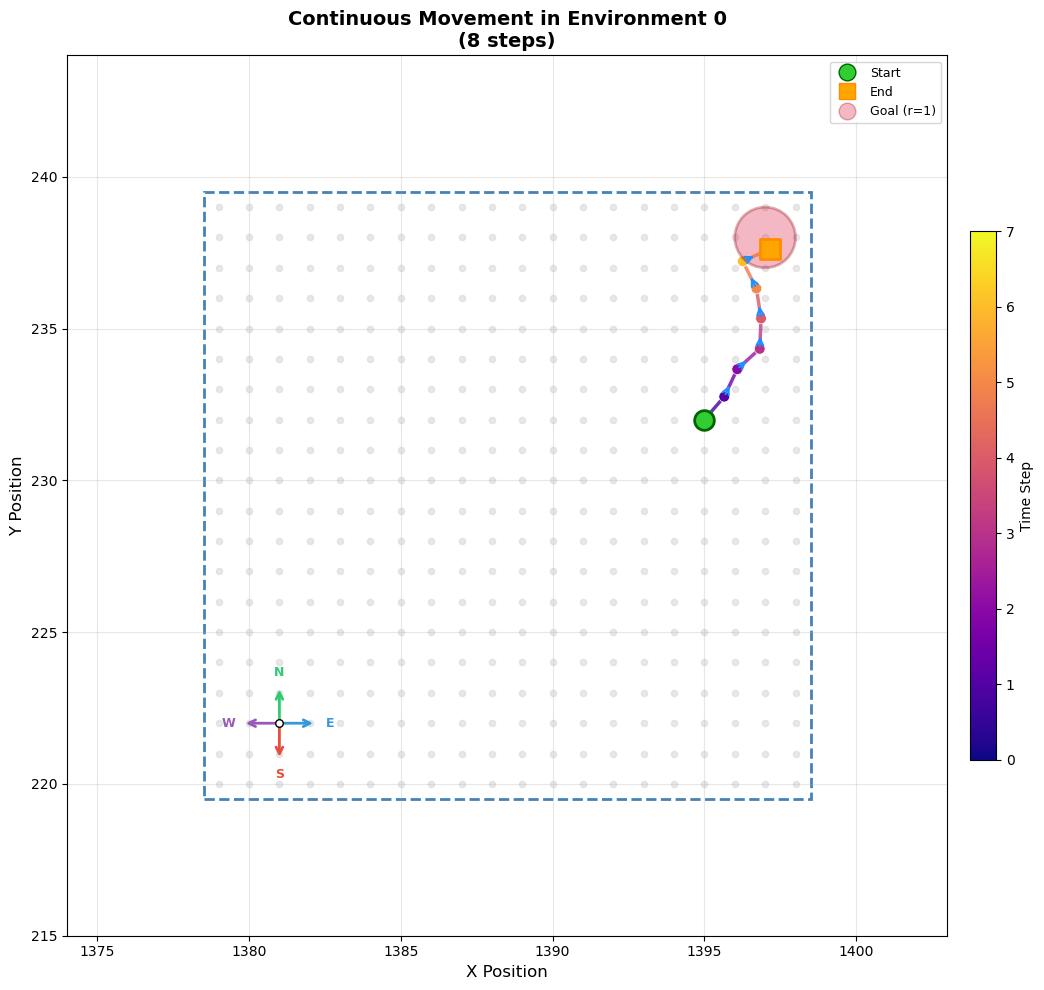


=== Environment 1 (Method: continous) ===
Start position (local): (4, 10)
Goal location (global): [1097  672]
Recompute interval: 1, Scale: 30.0, Normalize: False, Floor: 1.0, Platform radius: 1
Trajectory length: 6 steps
Final position: [1096.20924956  671.4364742 ]
Magnitudes (first 10): ['0.0137', '0.0090', '0.0087', '0.0086', '0.0059']


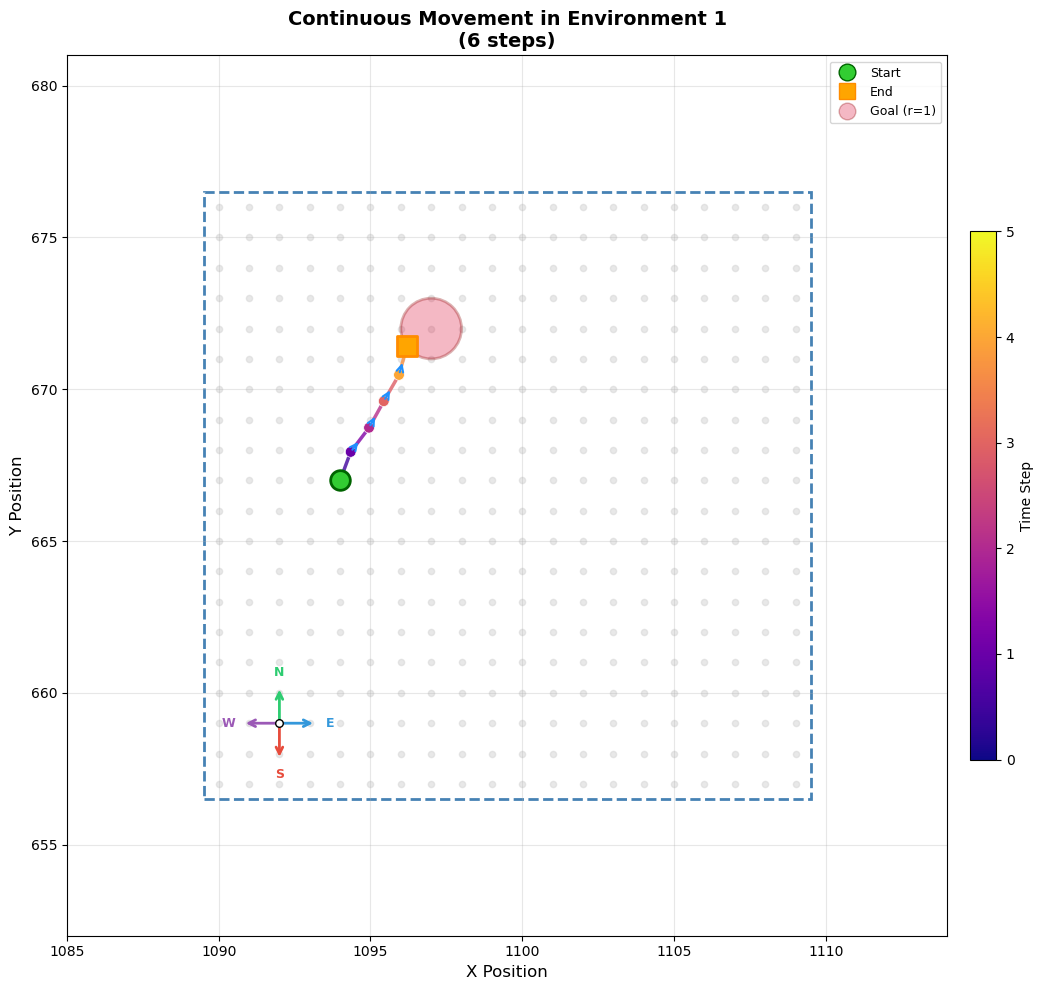


=== Environment 2 (Method: continous) ===
Start position (local): (4, 16)
Goal location (global): [550  85]
Recompute interval: 1, Scale: 30.0, Normalize: False, Floor: 1.0, Platform radius: 1
Trajectory length: 13 steps
Final position: [549.24383681  85.24562338]
Magnitudes (first 10): ['0.0211', '0.0180', '0.0171', '0.0164', '0.0143', '0.0110', '0.0092', '0.0066', '0.0049', '0.0057']


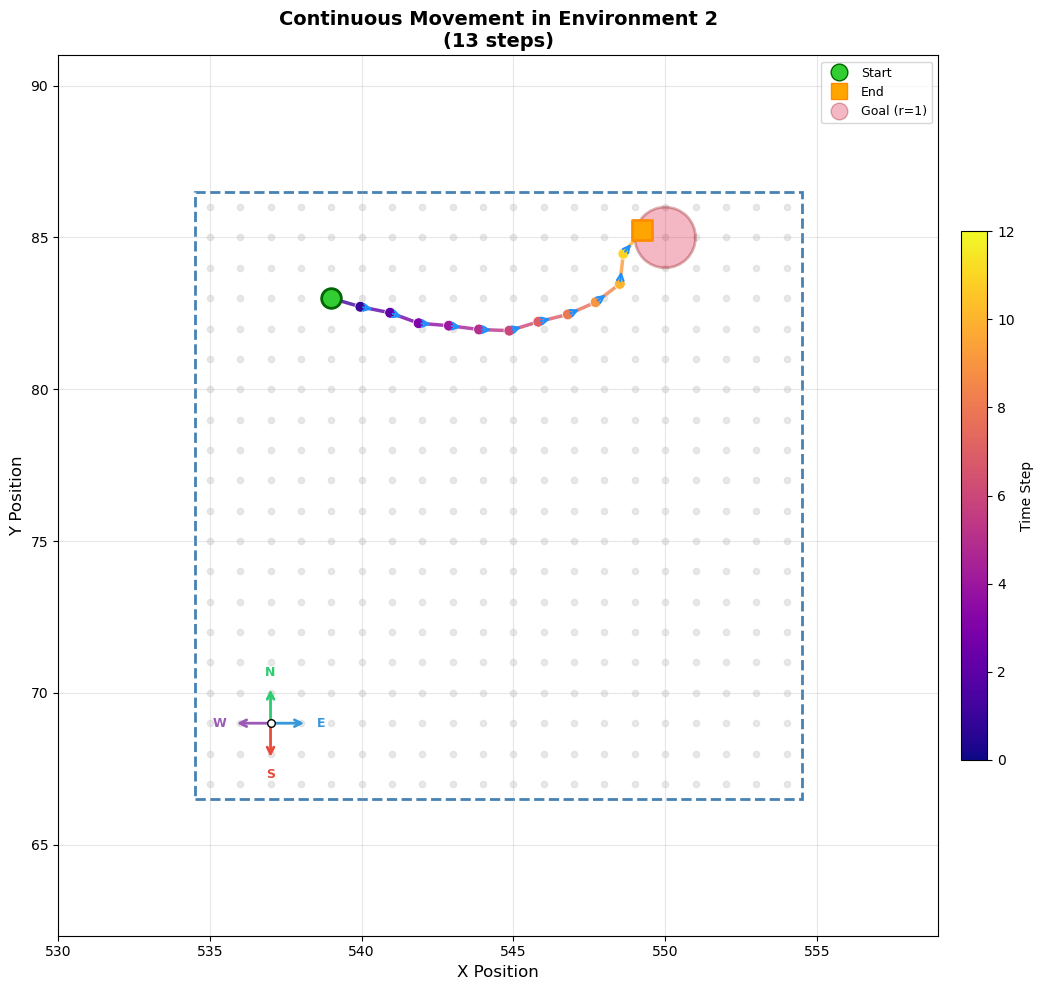


=== Combined View (3 environments) ===


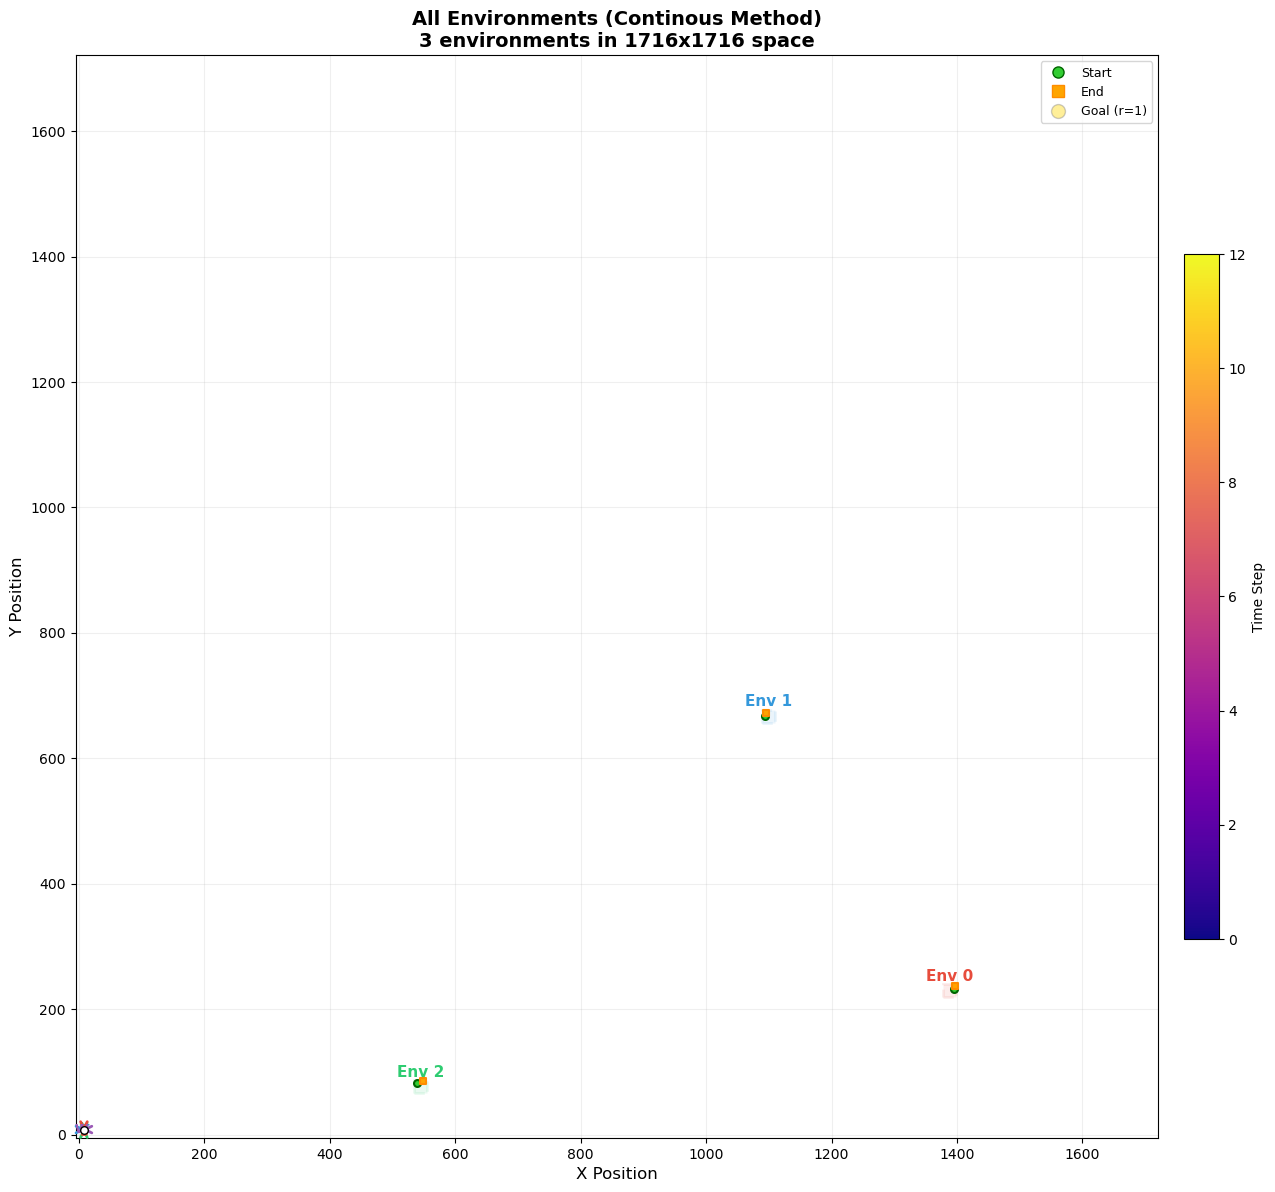

In [45]:
# Direction classification helpers
def compute_projection_matrix(d_forward, d_right):
    """Compute 2D projection matrix from forward/right basis vectors."""
    e1 = d_forward / np.linalg.norm(d_forward)
    e2 = d_right - np.dot(d_right, e1) * e1
    e2 = e2 / np.linalg.norm(e2)
    W = np.stack([e2, e1], axis=0)  # shape (2, n)
    return W

def project_query(W, d_query):
    """Project query vector into 2D space."""
    return W @ d_query  # shape (2,)

def classify_direction(q):
    """
    q: 2D vector [x, y]
    Returns: 0=Env_N, 1=Env_E, 2=Env_S, 3=Env_W
    """
    angle = np.arctan2(q[1], q[0])  # range: -pi to pi
    
    if -np.pi/4 <= angle < np.pi/4:
        return 1  # Env_E (right)
    elif np.pi/4 <= angle < 3*np.pi/4:
        return 0  # Env_N (forward)
    elif -3*np.pi/4 <= angle < -np.pi/4:
        return 2  # Env_S (backward)
    else:
        return 3  # Env_W (left)

# Randomly assign environment directions
# Base directions in CLOCKWISE order as they appear on plot: N, E, S, W
# On plot: y increases upward, x increases rightward
BASE_DIRECTIONS = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # N(up), E(right), S(down), W(left)
BASE_ARROWS = ['↑', '→', '↓', '←']

# Randomly pick which physical direction is Env_N
ENV_N_INDEX = np.random.randint(0, 4)

# Map direction class to (dx, dy) offsets - assigned clockwise from Env_N
DIRECTION_ARROWS = {
    0: BASE_DIRECTIONS[ENV_N_INDEX],           # Env_N
    1: BASE_DIRECTIONS[(ENV_N_INDEX + 1) % 4], # Env_E (clockwise from N)
    2: BASE_DIRECTIONS[(ENV_N_INDEX + 2) % 4], # Env_S (opposite N)
    3: BASE_DIRECTIONS[(ENV_N_INDEX + 3) % 4], # Env_W (counter-clockwise from N)
}

# Arrow symbols for legend
DIRECTION_ARROW_SYMBOLS = {
    0: BASE_ARROWS[ENV_N_INDEX],
    1: BASE_ARROWS[(ENV_N_INDEX + 1) % 4],
    2: BASE_ARROWS[(ENV_N_INDEX + 2) % 4],
    3: BASE_ARROWS[(ENV_N_INDEX + 3) % 4],
}

print(f"Random direction assignment (Env_N starts at base index {ENV_N_INDEX}):")
print(f"  Env_N: {DIRECTION_ARROWS[0]} {DIRECTION_ARROW_SYMBOLS[0]}")
print(f"  Env_E: {DIRECTION_ARROWS[1]} {DIRECTION_ARROW_SYMBOLS[1]}")
print(f"  Env_S: {DIRECTION_ARROWS[2]} {DIRECTION_ARROW_SYMBOLS[2]}")
print(f"  Env_W: {DIRECTION_ARROWS[3]} {DIRECTION_ARROW_SYMBOLS[3]}")

DIRECTION_NAMES = {0: 'Env_N', 1: 'Env_E', 2: 'Env_S', 3: 'Env_W'}
DIRECTION_COLORS = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c', 3: '#9b59b6'}  # green, blue, red, purple


def draw_compass_rose(ax, center_x, center_y, size=1.0):
    """Draw a compass rose showing Env_N/E/S/W directions."""
    labels = ['N', 'E', 'S', 'W']
    
    for i in range(4):
        dx, dy = DIRECTION_ARROWS[i]
        color = DIRECTION_COLORS[i]
        
        # Draw arrow
        ax.annotate('', 
                    xy=(center_x + dx * size, center_y + dy * size),
                    xytext=(center_x, center_y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2, mutation_scale=12),
                    zorder=10)
        
        # Add label at arrow tip
        ax.text(center_x + dx * size * 1.4, center_y + dy * size * 1.4, 
                labels[i], ha='center', va='center', fontsize=9, fontweight='bold',
                color=color, zorder=10)
    
    # Draw center dot
    ax.scatter(center_x, center_y, c='white', s=30, edgecolors='black', linewidths=1, zorder=11)


def compute_projection_matrix_at_pos(pos):
    """
    Compute the projection matrix W at a given position based on local Env_N/Env_E directions.
    Returns W and the current encoded state at that position.
    """
    x, y = pos
    # Clamp to valid range for neighbor access
    x = np.clip(x, 1, encoded_Phi.shape[0] - 2)
    y = np.clip(y, 1, encoded_Phi.shape[1] - 2)
    
    current = encoded_Phi[x, y].numpy()
    
    # Get neighbor offsets from random direction assignment
    dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
    de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
    
    # d_forward is direction TO Env_N neighbor
    d_forward = encoded_Phi[x + dn_dx, y + dn_dy].numpy() - current
    # d_right is direction TO Env_E neighbor
    d_right = encoded_Phi[x + de_dx, y + de_dy].numpy() - current
    
    W = compute_projection_matrix(d_forward, d_right)
    return W, current


def classify_with_matrix(W, current_np, next_state_np):
    """
    Classify direction using a pre-computed projection matrix W.
    
    Args:
        W: Pre-computed projection matrix (2, embed_dim)
        current_np: Current encoded state (used to compute direction vector)
        next_state_np: Next state from Hopfield
    
    Returns:
        direction class and the raw 2D projected vector
    """
    d_query = next_state_np - current_np
    q = project_query(W, d_query)
    direction = classify_direction(q)
    return direction, q


def get_local_direction(pos, next_state_np):
    """
    Compute the classified direction at a position given the next Hopfield state.
    Returns direction class and the raw 2D projected vector.
    (Convenience function that computes W fresh each time)
    """
    W, current = compute_projection_matrix_at_pos(pos)
    return classify_with_matrix(W, current, next_state_np)


def simulate_trajectory(env_idx, start_x, start_y, max_steps=50, convergence_threshold=1e-3, alpha=0.9):
    """
    Simulate agent movement using Hopfield rollout.
    The Hopfield output state is used directly to find the next position via nearest neighbor search.
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    trajectory = []
    directions = []  # Store direction class at each step
    projected_vecs = []  # Store raw 2D projected vectors
    
    location = env_indices[start_x, start_y].copy()
    trajectory.append(location.copy())
    
    state = encoded_Phi[location[0], location[1]]
    
    for step in range(max_steps):
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=alpha, use_tanh=True, normalize_each=True)
        
        # Compute direction classification
        direction, proj_vec = get_local_direction(location, next_state.numpy())
        directions.append(direction)
        projected_vecs.append(proj_vec)
        
        # Check for convergence
        if torch.norm(next_state - state) < convergence_threshold:
            break
            
        # Find closest position in encoded space
        sims = encoded_Phi @ next_state
        idx = torch.argmax(sims).item()
        row, col = divmod(idx, encoded_Phi.shape[1])
        
        location = np.array([row, col])
        trajectory.append(location.copy())
        state = next_state
        
        # Check if reached goal
        if np.array_equal(location, goal_loc):
            break
    
    return np.array(trajectory), directions, projected_vecs


# Map direction class to actual (dx, dy) step in grid coordinates (same as DIRECTION_ARROWS)
DIRECTION_STEPS = DIRECTION_ARROWS.copy()

def simulate_trajectory_discrete(env_idx, start_x, start_y, max_steps=50, bounds=None, recompute_interval=1, alpha=0.9):
    """
    Simulate agent movement using discrete stepping.
    
    1. Get Hopfield's next state from current encoded position
    2. Classify the direction (Env_N/Env_E/Env_S/Env_W)
    3. Take a discrete step in that direction
    4. Use the encoded state at the NEW physical position for next iteration
    
    Args:
        env_idx: Environment index
        start_x, start_y: Starting position (local coords within environment)
        max_steps: Maximum steps to take
        bounds: Optional (min_x, max_x, min_y, max_y) bounds, defaults to global encoded_Phi bounds
        recompute_interval: How often to recompute the projection matrix W.
                           1 = every step (default, same as before)
                           N = recompute every N steps
                           0 or negative = never recompute (use initial W for entire trajectory)
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    if bounds is None:
        min_x, max_x = 1, encoded_Phi.shape[0] - 2
        min_y, max_y = 1, encoded_Phi.shape[1] - 2
    else:
        min_x, max_x, min_y, max_y = bounds
    
    trajectory = []
    directions = []
    projected_vecs = []
    
    # Start position in global coordinates
    location = env_indices[start_x, start_y].copy()
    trajectory.append(location.copy())
    
    visited = set()
    visited.add(tuple(location))
    
    # Initialize projection matrix at start position
    W, W_origin_encoding = compute_projection_matrix_at_pos(location)
    steps_since_recompute = 0
    
    for step in range(max_steps):
        x, y = location
        
        # Get encoded state at CURRENT physical position
        state = encoded_Phi[x, y]
        current_np = state.numpy()
        
        # One Hopfield recall step
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=alpha, use_tanh=True, normalize_each=True)
        
        # Check if we need to recompute the projection matrix
        if recompute_interval > 0 and steps_since_recompute >= recompute_interval:
            W, W_origin_encoding = compute_projection_matrix_at_pos(location)
            steps_since_recompute = 0
        
        # Classify direction using (possibly cached) projection matrix
        # Note: We use current_np for the direction vector, but W defines the coordinate frame
        direction, proj_vec = classify_with_matrix(W, current_np, next_state.numpy())
        directions.append(direction)
        projected_vecs.append(proj_vec)
        steps_since_recompute += 1
        
        # Take a discrete step in that direction
        dx, dy = DIRECTION_STEPS[direction] #finding which way globally is North - imagine Agent has an internal representation of this
        new_x = np.clip(x + dx, min_x, max_x)
        new_y = np.clip(y + dy, min_y, max_y)
        new_location = np.array([new_x, new_y])
        
        # Check if we're stuck (same position after step)
        if np.array_equal(new_location, location):
            break
            
        # Check for loops (optional: can disable if you want to allow revisiting)
        if tuple(new_location) in visited:
            # Still record the position but will break after
            trajectory.append(new_location.copy())
            break
        
        visited.add(tuple(new_location))
        location = new_location
        trajectory.append(location.copy())
        
        # Check if reached goal
        if np.array_equal(location, goal_loc):
            break
    
    return np.array(trajectory), directions, projected_vecs


def get_continuous_step(W, current_np, next_state_np, scale=1.0, normalize=False, floor=0.0):
    """
    Compute a continuous movement vector from the Hopfield direction.
    
    Args:
        W: Projection matrix (2, embed_dim)
        current_np: Current encoded state
        next_state_np: Next state from Hopfield
        scale: Scale factor for steps (default 1.0)
        normalize: If True, normalize the step to unit length * scale.
                   If False, use raw projection magnitude * scale.
        floor: Minimum step size. If step would be smaller, scale up to floor.
    
    Returns:
        (dx, dy): Step in grid coordinates
        angle: Angle relative to forward (0 = forward, positive = clockwise)
        magnitude: Raw magnitude of projected vector
    """
    d_query = next_state_np - current_np
    q = project_query(W, d_query)  # q[0] = right, q[1] = forward
    
    magnitude = np.linalg.norm(q)
    
    if magnitude < 1e-8:
        return (0.0, 0.0), 0.0, 0.0
    
    if normalize:
        # Normalize to unit vector, then scale
        q_scaled = (q / magnitude) * scale
    else:
        # Use raw magnitude
        q_scaled = q * scale
    
    # Apply floor: if step is too small, scale up to floor
    step_magnitude = np.linalg.norm(q_scaled)
    if floor > 0 and step_magnitude < floor:
        q_scaled = (q_scaled / step_magnitude) * floor

    # Convert q components to grid (dx, dy) using the actual direction vectors
    # q[0] = component along Env_E, q[1] = component along Env_N
    dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
    de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
    
    # This step is again, assuming the agent knows what North is in this environment (head direction cell)
    dx = q_scaled[0] * de_dx + q_scaled[1] * dn_dx
    dy = q_scaled[0] * de_dy + q_scaled[1] * dn_dy
    
    # Angle relative to forward (0 = forward, positive = turning right)
    angle_from_forward = np.arctan2(q[0], q[1])
    
    return (dx, dy), angle_from_forward, magnitude


def simulate_trajectory_continuous(env_idx, start_x, start_y, max_steps=100, 
                                   scale=1.0, normalize=False, floor=0.0, platform_radius=0.5,
                                   bounds=None, recompute_interval=1, alpha=0.9):
    """
    Simulate agent movement using continuous stepping.
    
    The Hopfield direction is projected onto a 2D plane, and the resulting
    vector determines the movement step.
    
    Args:
        env_idx: Environment index
        start_x, start_y: Starting position (local coords within environment)
        max_steps: Maximum steps to take
        scale: Scale factor for steps (default 1.0)
        normalize: If True, normalize steps to unit length * scale (fixed step size).
                   If False, use raw projection magnitude * scale (variable step size).
        floor: Minimum step size. Steps smaller than this get scaled up.
        platform_radius: Stop when within this distance of the goal (default 0.5)
        bounds: Optional (min_x, max_x, min_y, max_y) bounds
        recompute_interval: How often to recompute projection matrix W
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    if bounds is None:
        min_x, max_x = 1, encoded_Phi.shape[0] - 2
        min_y, max_y = 1, encoded_Phi.shape[1] - 2
    else:
        min_x, max_x, min_y, max_y = bounds
    
    trajectory = []  # Will store continuous (float) positions
    angles = []      # Angle at each step
    magnitudes = []  # Magnitude at each step
    
    # Start position in global coordinates (continuous)
    start_loc = env_indices[start_x, start_y].astype(float)
    position = start_loc.copy()
    trajectory.append(position.copy())
    
    # Initialize projection matrix at start position
    W, _ = compute_projection_matrix_at_pos(np.round(position).astype(int))
    steps_since_recompute = 0
    
    for step in range(max_steps):
        # Discretize position for encoding lookup
        grid_pos = np.clip(np.round(position).astype(int), [min_x, min_y], [max_x, max_y])
        
        # Get encoded state at current (discretized) position
        state = encoded_Phi[grid_pos[0], grid_pos[1]]
        current_np = state.numpy()
        
        # One Hopfield recall step
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=alpha, 
                                   use_tanh=True, normalize_each=True)
        
        # Recompute projection matrix if needed
        if recompute_interval > 0 and steps_since_recompute >= recompute_interval:
            W, _ = compute_projection_matrix_at_pos(grid_pos)
            steps_since_recompute = 0
        
        # Get continuous step
        (dx, dy), angle, mag = get_continuous_step(W, current_np, next_state.numpy(), scale, normalize, floor)
        angles.append(angle)
        magnitudes.append(mag)
        steps_since_recompute += 1
        
        # Check for convergence (very small magnitude)
        if mag < 1e-6:
            break
        
        # Update position continuously
        new_position = position + np.array([dx, dy])
        
        # Clamp to bounds
        new_position[0] = np.clip(new_position[0], min_x, max_x)
        new_position[1] = np.clip(new_position[1], min_y, max_y)
        
        # Check if stuck
        if np.linalg.norm(new_position - position) < 1e-6:
            break
        
        position = new_position
        trajectory.append(position.copy())
        
        # Check if reached goal (within platform_radius)
        if np.linalg.norm(position - goal_loc) < platform_radius:
            break
    
    return np.array(trajectory), angles, magnitudes


def visualize_movement_continuous(env_idx, trajectory, angles, magnitudes, figsize=(12, 10), padding=1, show_arrows=True, show_legend=True, show_compass=True):
    """Visualize continuous agent movement with angle-based arrows."""
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    C_X, C_Y = C_pairs[env_idx]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot environment boundary
    env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size, 
                                fill=False, edgecolor='steelblue', linewidth=2, 
                                linestyle='--', label='Environment')
    ax.add_patch(env_bounds)
    
    # Plot all positions in environment (faint grid)
    pos = env_indices.reshape(-1, 2)
    ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=20, alpha=0.5, zorder=1)
    
    traj = np.array(trajectory)
    
    # Create color gradient for trajectory (by time step)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(traj)))
    
    # Plot trajectory line with gradient
    for i in range(len(traj) - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], 
                color=colors[i], linewidth=2.5, alpha=0.8, zorder=2)
    
    # Plot trajectory points colored by step number
    ax.scatter(traj[:, 0], traj[:, 1], c=np.arange(len(traj)), cmap='plasma', 
               s=60, edgecolors='white', linewidths=0.5, zorder=3)
    
    # Draw arrows showing movement direction (based on angle)
    if show_arrows:
        arrow_scale = 0.5
        dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
        de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
        
        for i in range(min(len(traj) - 1, len(angles))):
            angle = angles[i]
            # angle is relative to forward (Env_N), so:
            # forward_component = cos(angle), right_component = sin(angle)
            # Convert to grid coords using direction vectors
            adx = (np.cos(angle) * dn_dx + np.sin(angle) * de_dx) * arrow_scale
            ady = (np.cos(angle) * dn_dy + np.sin(angle) * de_dy) * arrow_scale
            
            ax.annotate('', 
                        xy=(traj[i, 0] + adx, traj[i, 1] + ady),
                        xytext=(traj[i, 0], traj[i, 1]),
                        arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=1.5, 
                                        mutation_scale=12),
                        zorder=6)
    
    # Mark start, end
    ax.scatter(traj[0, 0], traj[0, 1], c='limegreen', s=200, marker='o', 
               edgecolors='darkgreen', linewidths=2, zorder=7)
    ax.scatter(traj[-1, 0], traj[-1, 1], c='orange', s=200, marker='s', 
               edgecolors='darkorange', linewidths=2, zorder=7)
    
    # Goal platform (circle with PLATFORM_RADIUS)
    goal_circle = plt.Circle((goal_loc[0], goal_loc[1]), PLATFORM_RADIUS, 
                              fill=True, facecolor='crimson', alpha=0.3,
                              edgecolor='darkred', linewidth=2, zorder=4)
    ax.add_patch(goal_circle)
    
    # Formatting
    ax.set_xlim(C_X - padding, C_X + size + padding - 1)
    ax.set_ylim(C_Y - padding, C_Y + size + padding - 1)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position', fontsize=12)
    ax.set_ylabel('Y Position', fontsize=12)
    ax.set_title(f'Continuous Movement in Environment {env_idx}\n({len(traj)} steps)', 
                 fontsize=14, fontweight='bold')
    
    # Custom legend
    if show_legend:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen', 
                   markeredgecolor='darkgreen', markersize=12, label='Start'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', 
                   markeredgecolor='darkorange', markersize=12, label='End'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', alpha=0.3,
                   markeredgecolor='darkred', markersize=12, label=f'Goal (r={PLATFORM_RADIUS})'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add compass rose in lower-left
    if show_compass:
        compass_x = C_X + 2
        compass_y = C_Y + 2
        draw_compass_rose(ax, compass_x, compass_y, size=1.2)
    
    # Colorbar for time step
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(traj)-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Time Step', fontsize=10)
    
    plt.tight_layout()
    return fig, ax


def visualize_movement(env_idx, trajectory, directions, projected_vecs=None, figsize=(12, 10), padding=1, show_arrows=True, show_legend=True, show_compass=True):
    """Visualize agent movement within environment with direction arrows."""
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    C_X, C_Y = C_pairs[env_idx]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot environment boundary
    env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size, 
                                fill=False, edgecolor='steelblue', linewidth=2, linestyle='--', label='Environment')
    ax.add_patch(env_bounds)
    
    # Plot all positions in environment (faint grid)
    pos = env_indices.reshape(-1, 2)
    ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=20, alpha=0.5, zorder=1)
    
    # Plot trajectory
    traj = np.array(trajectory)
    
    # Create color gradient for trajectory (dark to light)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(traj)))
    
    # Plot trajectory line with gradient
    for i in range(len(traj) - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], 
                color=colors[i], linewidth=2.5, alpha=0.8, zorder=2)
    
    # Plot trajectory points
    ax.scatter(traj[:, 0], traj[:, 1], c=np.arange(len(traj)), cmap='plasma', 
               s=60, edgecolors='white', linewidths=0.5, zorder=3)
    
    # Draw direction arrows at each trajectory point
    if show_arrows:
        arrow_scale = 0.6  # Scale factor for arrow length
        for i, (point, direction) in enumerate(zip(traj[:-1], directions)):  # Skip last point (no next state)
            dx, dy = DIRECTION_ARROWS[direction]
            arrow_color = DIRECTION_COLORS[direction]
            
            ax.annotate('', 
                        xy=(point[0] + dx * arrow_scale, point[1] + dy * arrow_scale),
                        xytext=(point[0], point[1]),
                        arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2.5, 
                                        mutation_scale=15),
                        zorder=6)
    
    # Mark start position
    ax.scatter(traj[0, 0], traj[0, 1], c='limegreen', s=200, marker='o', 
               edgecolors='darkgreen', linewidths=2, zorder=7)
    
    # Mark end position
    ax.scatter(traj[-1, 0], traj[-1, 1], c='orange', s=200, marker='s', 
               edgecolors='darkorange', linewidths=2, zorder=7)
    
    # Goal platform (circle with PLATFORM_RADIUS)
    goal_circle = plt.Circle((goal_loc[0], goal_loc[1]), PLATFORM_RADIUS, 
                              fill=True, facecolor='crimson', alpha=0.3,
                              edgecolor='darkred', linewidth=2, zorder=4)
    ax.add_patch(goal_circle)
    
    # Formatting
    ax.set_xlim(C_X - padding, C_X + size + padding - 1)
    ax.set_ylim(C_Y - padding, C_Y + size + padding - 1)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position', fontsize=12)
    ax.set_ylabel('Y Position', fontsize=12)
    ax.set_title(f'Agent Movement in Environment {env_idx}\n({len(traj)} steps)', fontsize=14, fontweight='bold')
    
    # Custom legend with direction colors
    if show_legend:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen', 
                   markeredgecolor='darkgreen', markersize=12, label='Start'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', 
                   markeredgecolor='darkorange', markersize=12, label='End'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', alpha=0.3,
                   markeredgecolor='darkred', markersize=12, label=f'Goal (r={PLATFORM_RADIUS})'),
            Line2D([0], [0], color=DIRECTION_COLORS[0], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[0]} Env_N'),
            Line2D([0], [0], color=DIRECTION_COLORS[1], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[1]} Env_E'),
            Line2D([0], [0], color=DIRECTION_COLORS[2], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[2]} Env_S'),
            Line2D([0], [0], color=DIRECTION_COLORS[3], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[3]} Env_W'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add compass rose in lower-left
    if show_compass:
        compass_x = C_X + 2
        compass_y = C_Y + 2
        draw_compass_rose(ax, compass_x, compass_y, size=1.2)
    
    # Add colorbar for time
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(traj)-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Time Step', fontsize=10)
    
    plt.tight_layout()
    return fig, ax


def visualize_all_envs(results, method='discrete', figsize=(14, 14), show_legend=True, show_compass=True):
    """
    Visualize all environments on a single plot in the full Npos x Npos space.
    
    Args:
        results: List of tuples, one per environment:
            - For 'discrete'/'hopfield': (env_idx, trajectory, directions)
            - For 'continuous': (env_idx, trajectory, angles, magnitudes)
        method: 'discrete', 'hopfield', or 'continuous'
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define distinct colors for each environment's trajectory
    env_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
    
    # Plot all environment boundaries
    for env_idx in range(n_envs):
        C_X, C_Y = C_pairs[env_idx]
        env_color = env_colors[env_idx % len(env_colors)]
        
        # Environment boundary
        env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size, 
                                    fill=True, facecolor=env_color, alpha=0.1,
                                    edgecolor=env_color, linewidth=2, linestyle='--')
        ax.add_patch(env_bounds)
        
        # Environment label
        ax.text(C_X + size/2, C_Y + size + 1, f'Env {env_idx}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold', color=env_color)
        
        # Goal platform (circle with PLATFORM_RADIUS)
        goal_loc = goal_locations[env_idx]
        goal_circle = plt.Circle((goal_loc[0], goal_loc[1]), PLATFORM_RADIUS, 
                                  fill=True, facecolor='gold', alpha=0.4,
                                  edgecolor=env_color, linewidth=1.5, zorder=5)
        ax.add_patch(goal_circle)
    
    # Plot trajectories for each environment
    max_steps = 0
    for result in results:
        env_idx = result[0]
        traj = np.array(result[1])
        max_steps = max(max_steps, len(traj))
        env_color = env_colors[env_idx % len(env_colors)]
        C_X, C_Y = C_pairs[env_idx]
        
        # Create color gradient for trajectory (by time step)
        colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(traj)))
        
        # Plot trajectory line with gradient
        for i in range(len(traj) - 1):
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], 
                    color=colors[i], linewidth=2, alpha=0.8, zorder=3)
        
        # Plot trajectory points
        ax.scatter(traj[:, 0], traj[:, 1], c=np.arange(len(traj)), cmap='plasma', 
                   s=10, edgecolors='white', linewidths=0.3, zorder=4, vmin=0, vmax=len(traj)-1)
        
        # Mark start position
        ax.scatter(traj[0, 0], traj[0, 1], c='limegreen', s=25, marker='o', 
                   edgecolors='darkgreen', linewidths=1.5, zorder=7)
        
        # Mark end position  
        ax.scatter(traj[-1, 0], traj[-1, 1], c='orange', s=25, marker='s', 
                   edgecolors='darkorange', linewidths=1.5, zorder=7)
    
    # Formatting - full Npos x Npos bounds with padding
    padding = 5
    ax.set_xlim(-padding, Npos + padding)
    ax.set_ylim(-padding, Npos + padding)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position', fontsize=12)
    ax.set_ylabel('Y Position', fontsize=12)
    ax.set_title(f'All Environments ({method.capitalize()} Method)\n{n_envs} environments in {Npos}x{Npos} space', 
                 fontsize=14, fontweight='bold')
    
    # Legend
    if show_legend:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen', 
                   markeredgecolor='darkgreen', markersize=8, label='Start'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', 
                   markeredgecolor='darkorange', markersize=8, label='End'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', alpha=0.4,
                   markeredgecolor='gray', markersize=10, label=f'Goal (r={PLATFORM_RADIUS})'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)
    
    # Add compass rose in lower-left corner
    if show_compass:
        compass_x = 8
        compass_y = 8
        draw_compass_rose(ax, compass_x, compass_y, size=3)
    
    # Colorbar for time
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, max_steps-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label('Time Step', fontsize=10)
    
    plt.tight_layout()
    return fig, ax


# Choose simulation method: 'hopfield', 'discrete', or 'continuous'
# - 'hopfield': Uses Hopfield output state directly to find next position (nearest neighbor)
# - 'discrete': Classifies direction from Hopfield output, takes discrete step (±1), uses new position's encoding
# - 'continuous': Uses projection magnitude directly for continuous movement steps
METHOD = 'continous'  # Change to 'hopfield', 'discrete', or 'continuous'

# For 'discrete' and 'continuous' methods: how often to recompute the projection matrix W
# - 1 = every step (recompute at each new position, default behavior)
# - N = every N steps (use same W for N steps before recomputing)
# - 0 = never (use initial W from start position for entire trajectory)
RECOMPUTE_INTERVAL = 1

# For 'continuous' method:
SCALE = 30.0          # Scale factor for steps
NORMALIZE = False      # If True: fixed step size (unit direction * scale)
                       # If False: variable step size (raw magnitude * scale)
FLOOR = 1.0             # Minimum step size (0 = no floor)
PLATFORM_RADIUS = 1  # Stop when within this distance of goal

ALPHA = 0.8

# Visualization options
SHOW_INDIVIDUAL = True   # Show individual per-environment plots
SHOW_COMBINED = True     # Show combined plot with all environments
SHOW_ARROWS = True      # Show direction arrows on trajectory points
SHOW_LEGEND = True       # Show legend
SHOW_COMPASS = True      # Show compass rose
PADDING = 5

# Collect results for combined visualization
all_results = []

# Run simulation and visualize for each environment
for env_idx in range(n_envs):
    # Random start position within environment
    start_x = np.random.randint(0, size)
    start_y = np.random.randint(0, size)
    # start_x = 4
    # start_y = 9
    
    print(f"\n=== Environment {env_idx} (Method: {METHOD}) ===")
    print(f"Start position (local): ({start_x}, {start_y})")
    print(f"Goal location (global): {goal_locations[env_idx]}")
    
    if METHOD == 'hopfield':
        trajectory, directions, projected_vecs = simulate_trajectory(env_idx, start_x, start_y, max_steps=100, alpha=ALPHA)
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Directions taken: {[DIRECTION_NAMES[d] for d in directions]}")
        all_results.append((env_idx, trajectory, directions))
        if SHOW_INDIVIDUAL:
            visualize_movement(env_idx, trajectory, directions, projected_vecs, padding=PADDING, show_arrows=SHOW_ARROWS, show_legend=SHOW_LEGEND, show_compass=SHOW_COMPASS)
        
    elif METHOD == 'discrete':
        print(f"Recompute interval: {RECOMPUTE_INTERVAL} {'(every step)' if RECOMPUTE_INTERVAL == 1 else '(never)' if RECOMPUTE_INTERVAL <= 0 else f'(every {RECOMPUTE_INTERVAL} steps)'}")
        trajectory, directions, projected_vecs = simulate_trajectory_discrete(
            env_idx, start_x, start_y, max_steps=100, recompute_interval=RECOMPUTE_INTERVAL, alpha=ALPHA
        )
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Directions taken: {[DIRECTION_NAMES[d] for d in directions]}")
        all_results.append((env_idx, trajectory, directions))
        if SHOW_INDIVIDUAL:
            visualize_movement(env_idx, trajectory, directions, projected_vecs, padding=PADDING, show_arrows=SHOW_ARROWS, show_legend=SHOW_LEGEND, show_compass=SHOW_COMPASS)
        
    else:  # continuous
        print(f"Recompute interval: {RECOMPUTE_INTERVAL}, Scale: {SCALE}, Normalize: {NORMALIZE}, Floor: {FLOOR}, Platform radius: {PLATFORM_RADIUS}")
        trajectory, angles, magnitudes = simulate_trajectory_continuous(
            env_idx, start_x, start_y, max_steps=100, scale=SCALE, normalize=NORMALIZE, floor=FLOOR, 
            platform_radius=PLATFORM_RADIUS, recompute_interval=RECOMPUTE_INTERVAL, alpha=ALPHA
        )
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Magnitudes (first 10): {[f'{m:.4f}' for m in magnitudes[:10]]}")
        all_results.append((env_idx, trajectory, angles, magnitudes))
        if SHOW_INDIVIDUAL:
            visualize_movement_continuous(env_idx, trajectory, angles, magnitudes, padding=PADDING, show_arrows=SHOW_ARROWS, show_legend=SHOW_LEGEND, show_compass=SHOW_COMPASS)
    
    if SHOW_INDIVIDUAL:
        plt.show()

# Combined visualization of all environments
if SHOW_COMBINED and all_results:
    print(f"\n=== Combined View ({n_envs} environments) ===")
    visualize_all_envs(all_results, method=METHOD, show_legend=SHOW_LEGEND, show_compass=SHOW_COMPASS)
    plt.show()

Running 25 trajectories (stride=4) for Env 0  [method=continuous]
Done – collected 25 trajectories


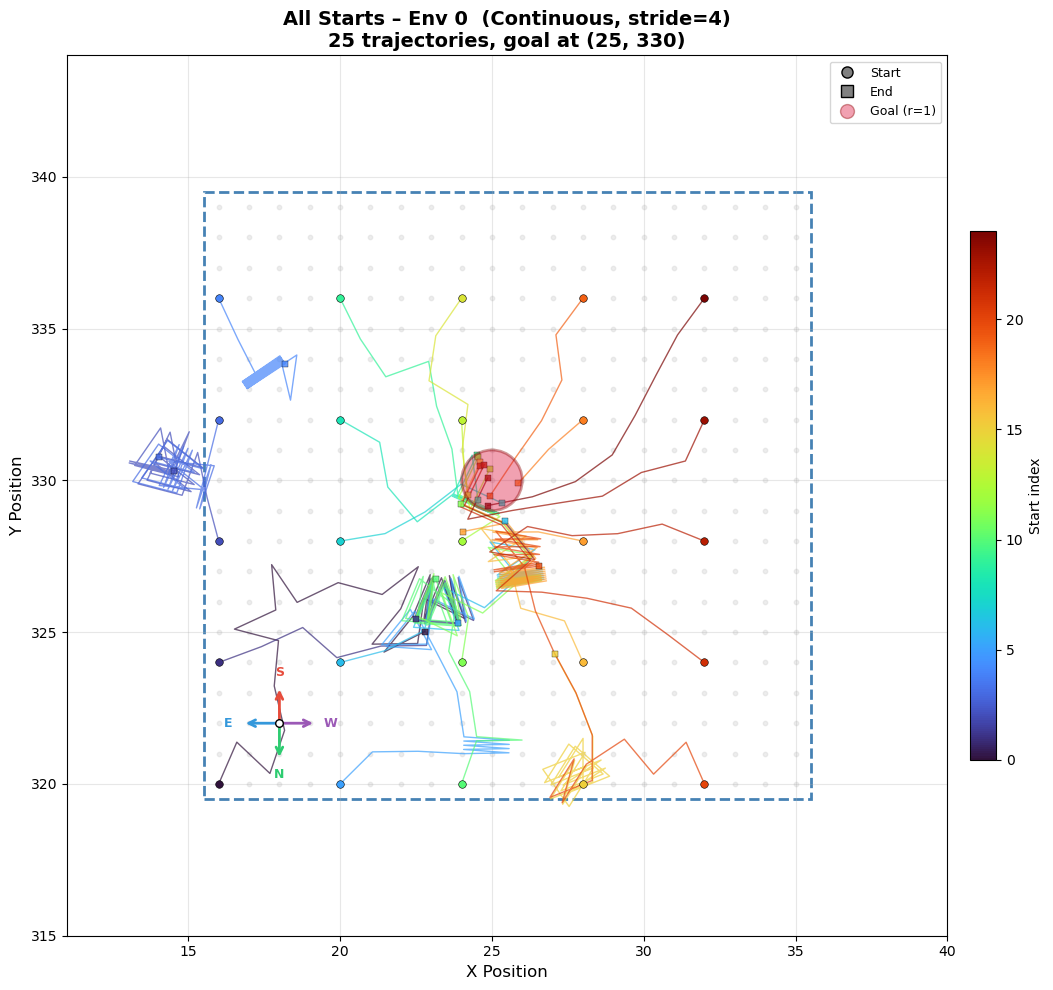

In [ ]:
## ── Visualize trajectories from ALL starting positions in one environment ──

# Choose simulation method: 'hopfield', 'discrete', or 'continuous'
# - 'hopfield': Uses Hopfield output state directly to find next position (nearest neighbor)
# - 'discrete': Classifies direction from Hopfield output, takes discrete step (±1), uses new position's encoding
# - 'continuous': Uses projection magnitude directly for continuous movement steps
METHOD = 'continuous'  # Change to 'hopfield', 'discrete', or 'continuous'

# For 'discrete' and 'continuous' methods: how often to recompute the projection matrix W
# - 1 = every step (recompute at each new position, default behavior)
# - N = every N steps (use same W for N steps before recomputing)
# - 0 = never (use initial W from start position for entire trajectory)
RECOMPUTE_INTERVAL = 1

# For 'continuous' method:
SCALE = 30.0          # Scale factor for steps
NORMALIZE = False      # If True: fixed step size (unit direction * scale)
                       # If False: variable step size (raw magnitude * scale)
FLOOR = 1.5             # Minimum step size (0 = no floor)
PLATFORM_RADIUS = 1  # Stop when within this distance of goal

ALPHA = 0.8

# Visualization options
SHOW_INDIVIDUAL = True   # Show individual per-environment plots
SHOW_COMBINED = True     # Show combined plot with all environments
SHOW_ARROWS = True      # Show direction arrows on trajectory points
SHOW_LEGEND = True       # Show legend
SHOW_COMPASS = True      # Show compass rose
PADDING = 5

# ── Config ──
ENV_IDX_TO_PLOT = 0          # Which environment to plot
START_STRIDE = 4             # Stride for subsampling start positions (1 = every cell, 2 = every other, etc.)

# Reuses: METHOD, SCALE, NORMALIZE, FLOOR, PLATFORM_RADIUS, ALPHA, RECOMPUTE_INTERVAL,
#         SHOW_ARROWS, SHOW_LEGEND, SHOW_COMPASS, PADDING  (from the cell above)

# ── Gather trajectories from every (subsampled) start ──
env_idx = ENV_IDX_TO_PLOT
env_indices = all_env_indices[env_idx]
goal_loc = goal_locations[env_idx]
C_X, C_Y = C_pairs[env_idx]

start_xs = np.arange(0, size, START_STRIDE)
start_ys = np.arange(0, size, START_STRIDE)
n_starts = len(start_xs) * len(start_ys)
print(f"Running {n_starts} trajectories (stride={START_STRIDE}) for Env {env_idx}  [method={METHOD}]")

trajectories = []   # list of np arrays, one per start
start_locs = []     # (sx, sy) local coords

for sx in start_xs:
    for sy in start_ys:
        if METHOD == 'hopfield':
            traj, _, _ = simulate_trajectory(env_idx, sx, sy, max_steps=25, alpha=ALPHA)
        elif METHOD == 'discrete':
            traj, _, _ = simulate_trajectory_discrete(
                env_idx, sx, sy, max_steps=25,
                recompute_interval=RECOMPUTE_INTERVAL, alpha=ALPHA)
        else:  # continuous
            traj, _, _ = simulate_trajectory_continuous(
                env_idx, sx, sy, max_steps=25,
                scale=SCALE, normalize=NORMALIZE, floor=FLOOR,
                platform_radius=PLATFORM_RADIUS,
                recompute_interval=RECOMPUTE_INTERVAL, alpha=ALPHA)
        trajectories.append(np.array(traj))
        start_locs.append((sx, sy))

print(f"Done – collected {len(trajectories)} trajectories")

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 10))

# Environment boundary
env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size,
                            fill=False, edgecolor='steelblue',
                            linewidth=2, linestyle='--', label='Environment')
ax.add_patch(env_bounds)

# Faint grid of all positions
pos = env_indices.reshape(-1, 2)
ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=10, alpha=0.4, zorder=1)

# Colour each trajectory by a start-position index
cmap = plt.cm.turbo
norm = plt.Normalize(0, len(trajectories) - 1)

for idx, traj in enumerate(trajectories):
    color = cmap(norm(idx))
    # trajectory line
    ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=1.0, alpha=0.7, zorder=2)
    # start marker
    ax.scatter(traj[0, 0], traj[0, 1], c=[color], s=30, marker='o',
               edgecolors='k', linewidths=0.4, zorder=5)
    # end marker
    ax.scatter(traj[-1, 0], traj[-1, 1], c=[color], s=20, marker='s',
               edgecolors='k', linewidths=0.3, alpha=0.8, zorder=5)

# Goal
goal_circle = plt.Circle((goal_loc[0], goal_loc[1]), PLATFORM_RADIUS,
                          fill=True, facecolor='crimson', alpha=0.4,
                          edgecolor='darkred', linewidth=2, zorder=6)
ax.add_patch(goal_circle)

# Compass rose
if SHOW_COMPASS:
    draw_compass_rose(ax, C_X + 2, C_Y + 2, size=1.2)

# Formatting
ax.set_xlim(C_X - PADDING, C_X + size + PADDING - 1)
ax.set_ylim(C_Y - PADDING, C_Y + size + PADDING - 1)
ax.set_aspect('equal')
ax.set_xlabel('X Position', fontsize=12)
ax.set_ylabel('Y Position', fontsize=12)
ax.set_title(
    f'All Starts – Env {env_idx}  ({METHOD.capitalize()}, stride={START_STRIDE})\n'
    f'{n_starts} trajectories, goal at {tuple(goal_loc)}',
    fontsize=14, fontweight='bold')

if SHOW_LEGEND:
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=8, label='Start'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=8, label='End'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
               alpha=0.4, markeredgecolor='darkred', markersize=10,
               label=f'Goal (r={PLATFORM_RADIUS})'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Colorbar keyed to start-position index
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Start index', fontsize=10)

plt.tight_layout()
plt.show()

Placed 10 eval environments (20x20), stored 10 goals in Hopfield
  Env  0 | acc=0.58 | dir_acc_succ=0.84 | dir_acc_fail=0.60 | mean_steps= 19.6 | speed=0.594 | dist_succ=0.60 | dist_fail=6.56
  Env  1 | acc=0.17 | dir_acc_succ=1.00 | dir_acc_fail=0.58 | mean_steps=  6.8 | speed=0.974 | dist_succ=0.71 | dist_fail=3.61
  Env  2 | acc=0.61 | dir_acc_succ=0.80 | dir_acc_fail=0.59 | mean_steps= 24.7 | speed=0.602 | dist_succ=0.86 | dist_fail=6.58
  Env  3 | acc=0.10 | dir_acc_succ=0.85 | dir_acc_fail=0.48 | mean_steps=  7.8 | speed=0.770 | dist_succ=0.63 | dist_fail=5.54
  Env  4 | acc=0.10 | dir_acc_succ=0.97 | dir_acc_fail=0.55 | mean_steps=  9.6 | speed=0.914 | dist_succ=0.53 | dist_fail=6.22
  Env  5 | acc=0.48 | dir_acc_succ=1.00 | dir_acc_fail=0.54 | mean_steps=  7.2 | speed=0.983 | dist_succ=0.64 | dist_fail=6.05
  Env  6 | acc=0.10 | dir_acc_succ=0.83 | dir_acc_fail=0.59 | mean_steps= 15.4 | speed=0.692 | dist_succ=0.61 | dist_fail=9.37
  Env  7 | acc=0.83 | dir_acc_succ=0.95 | dir_

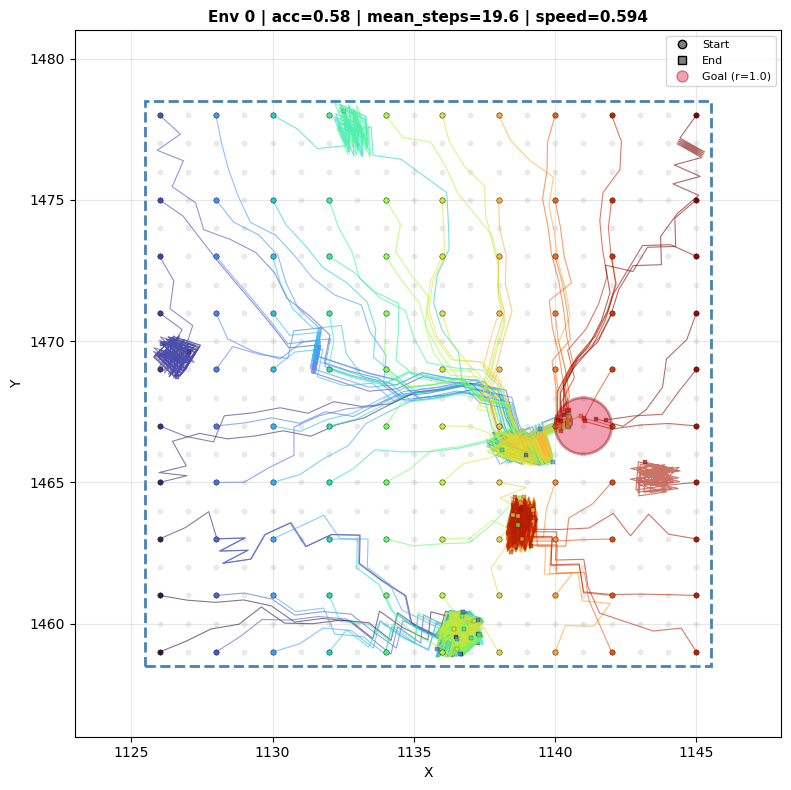

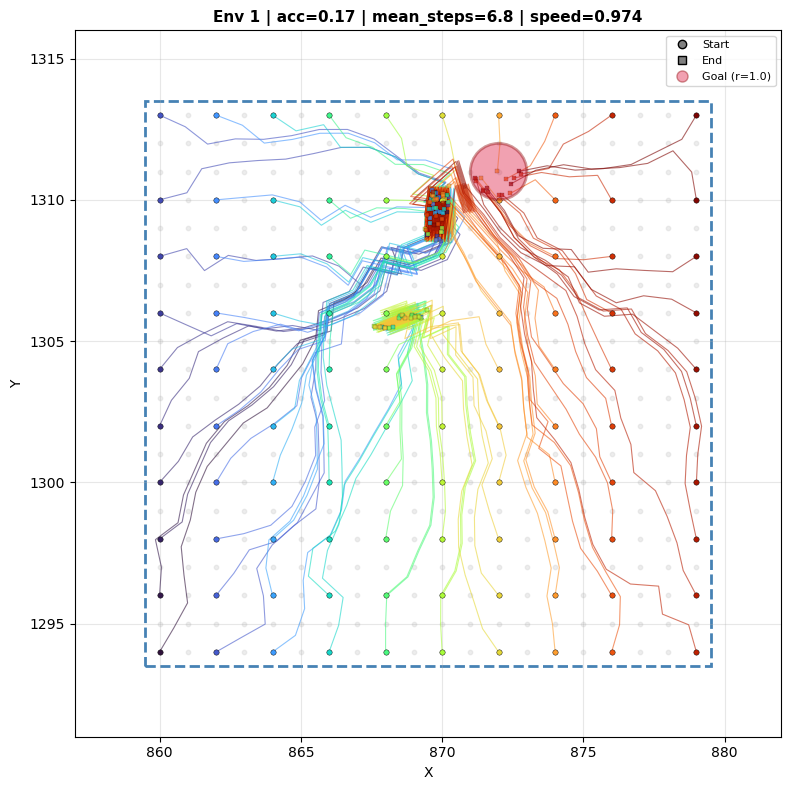

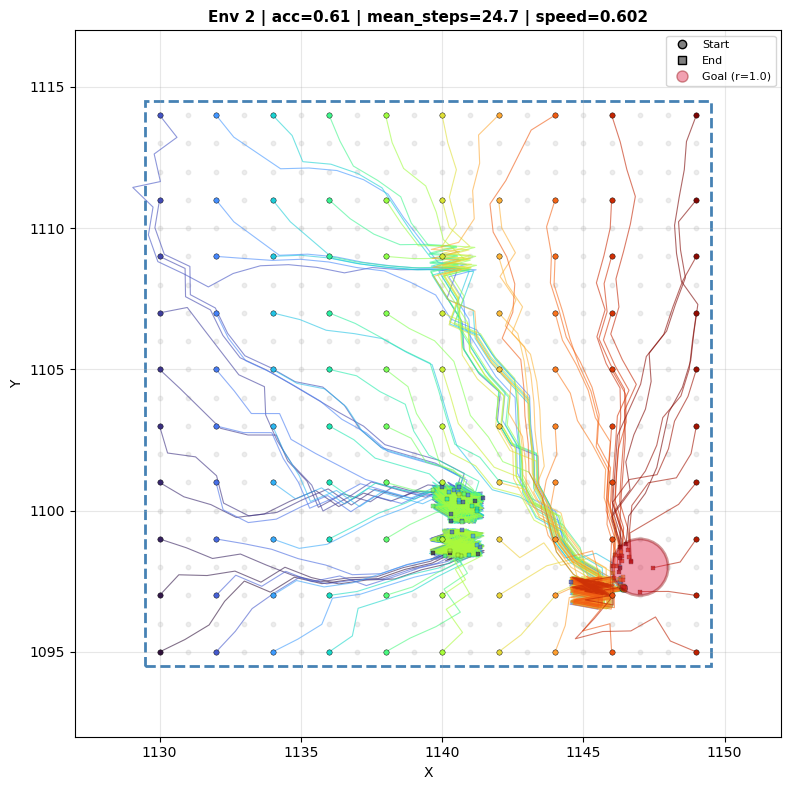

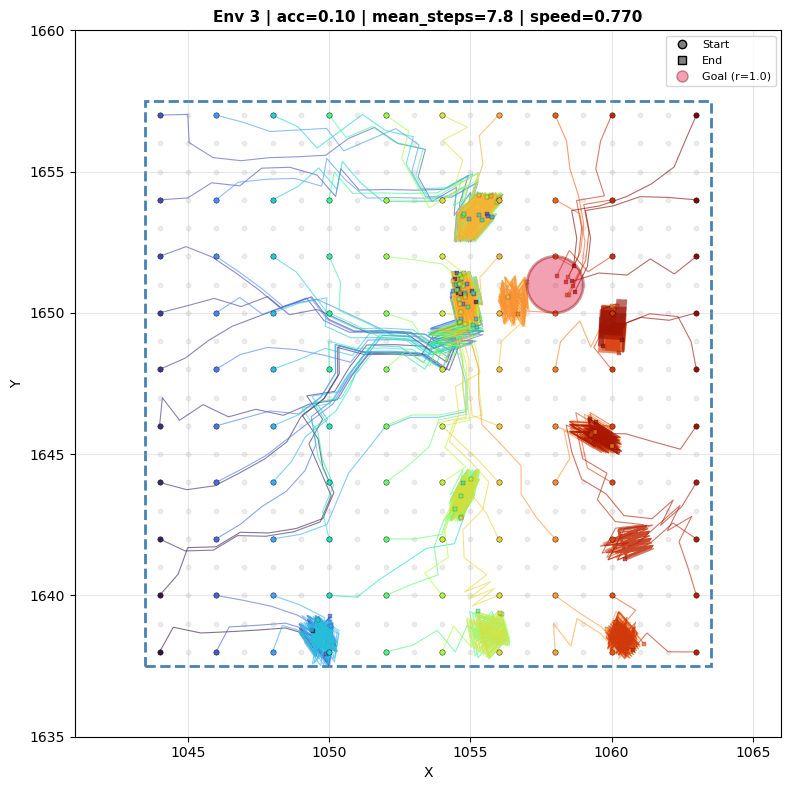

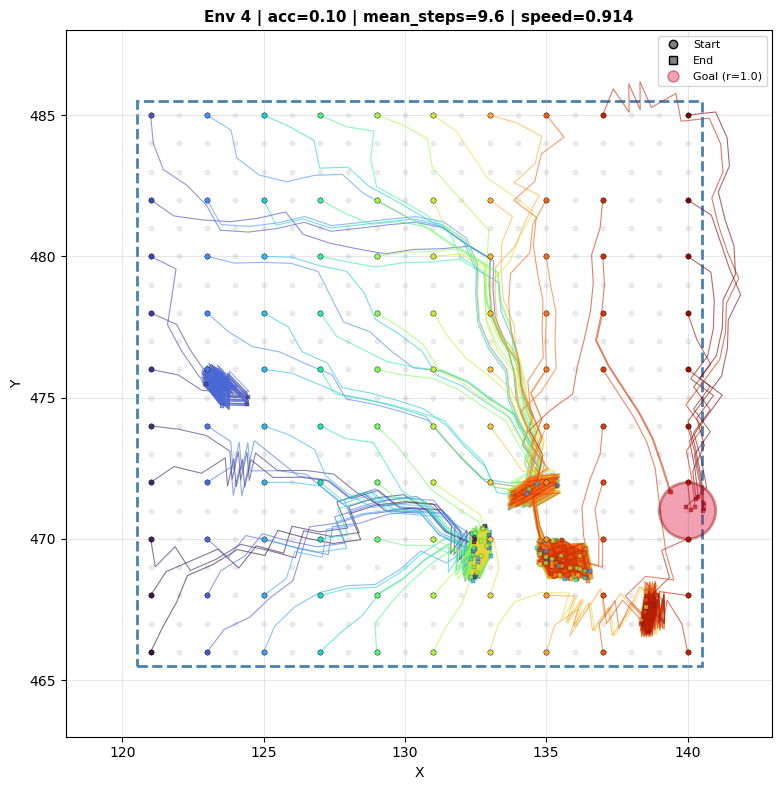

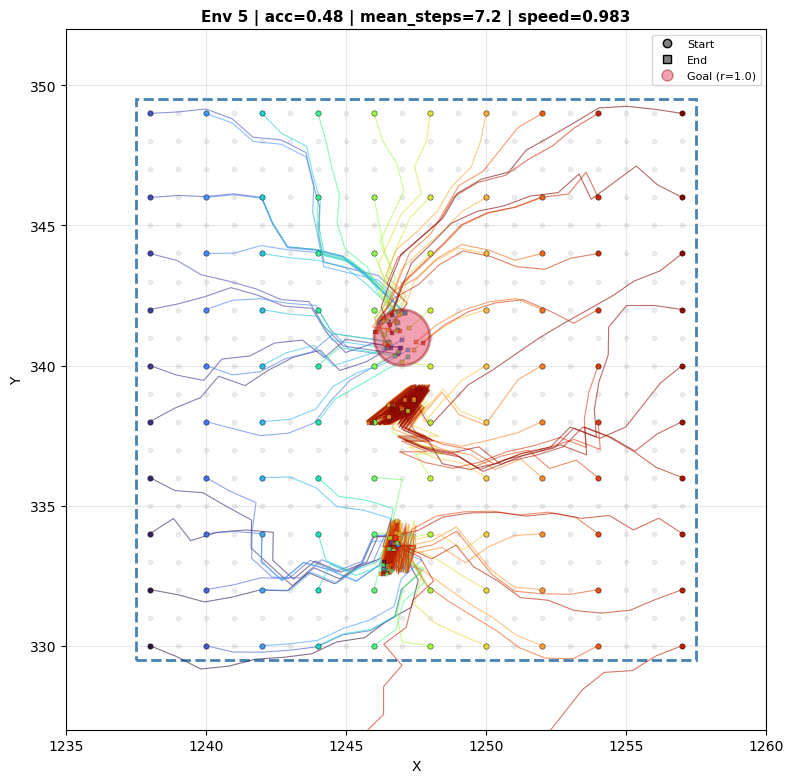

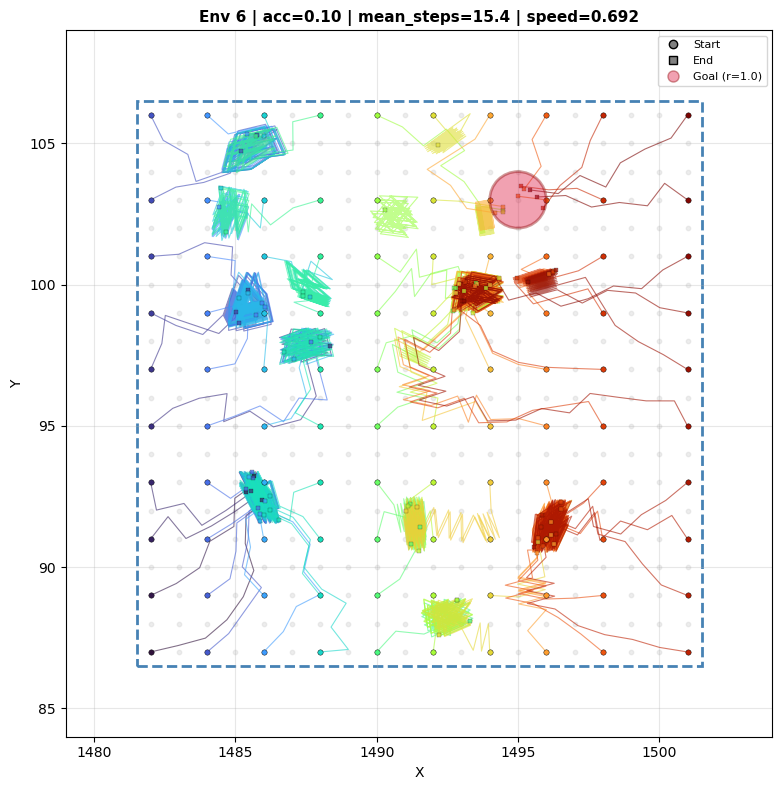

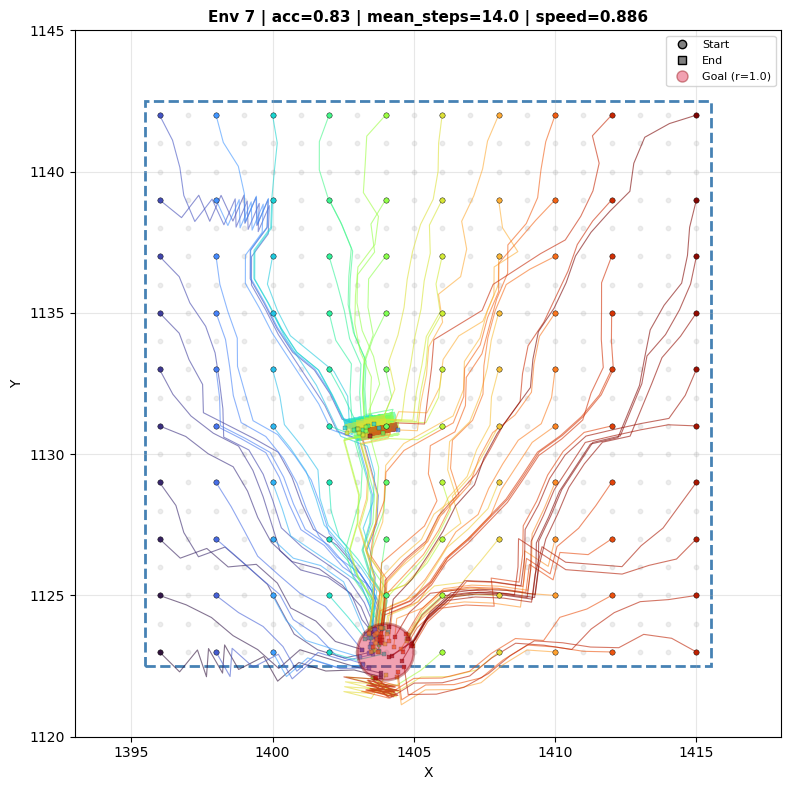

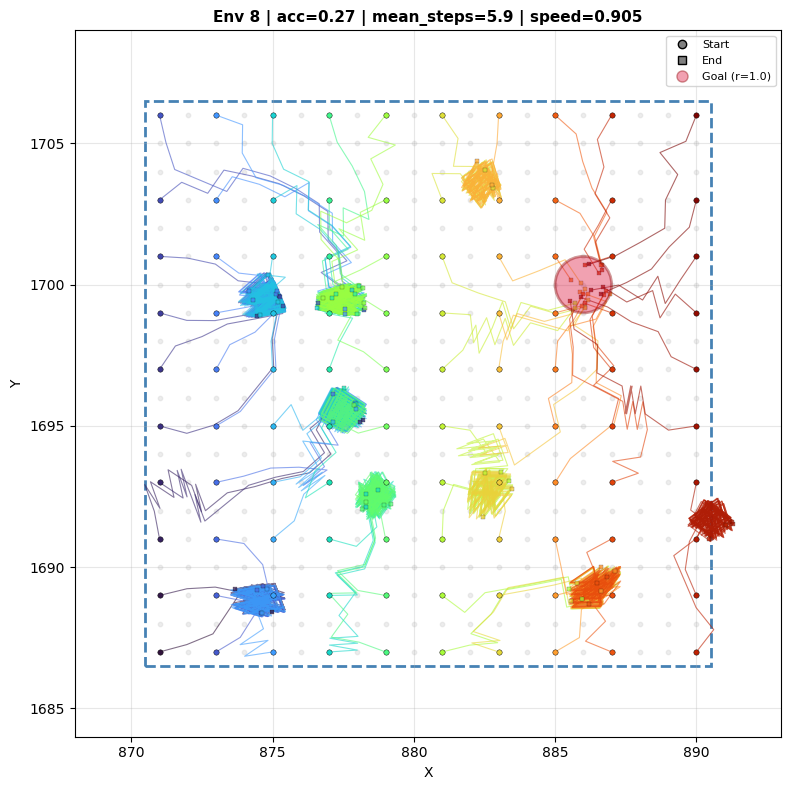

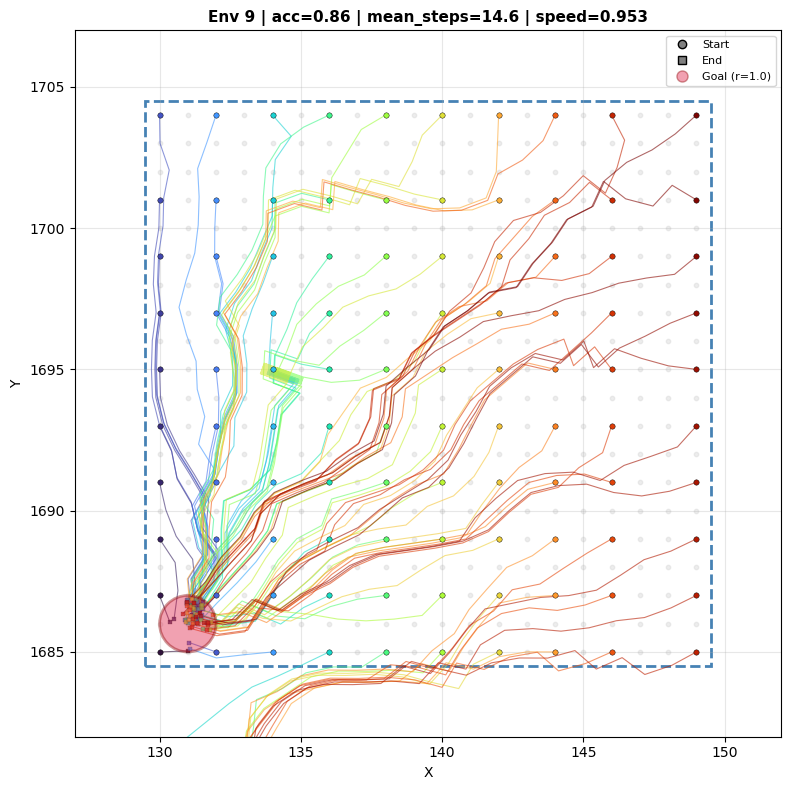

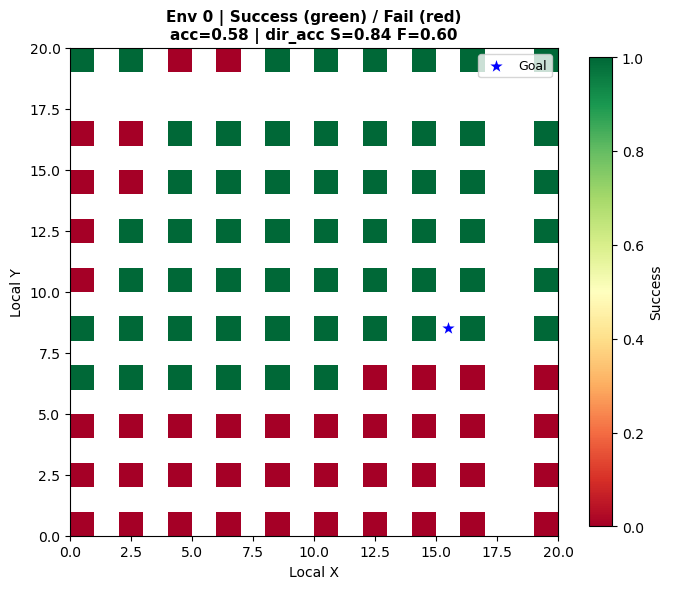

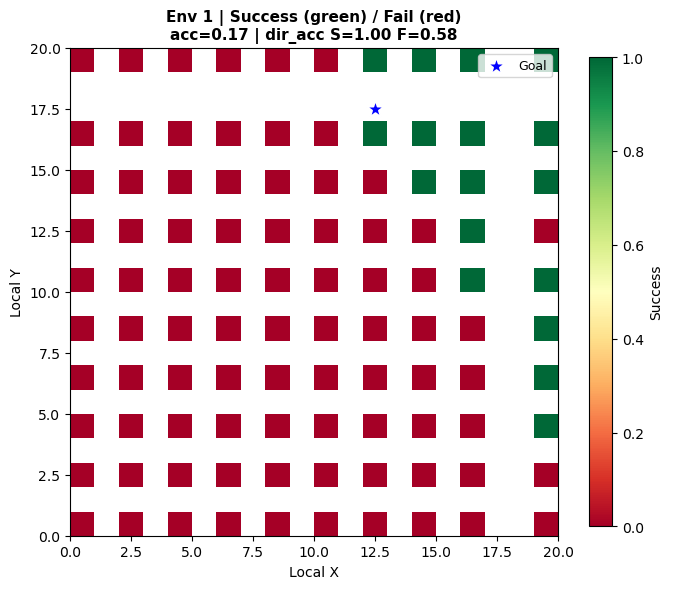

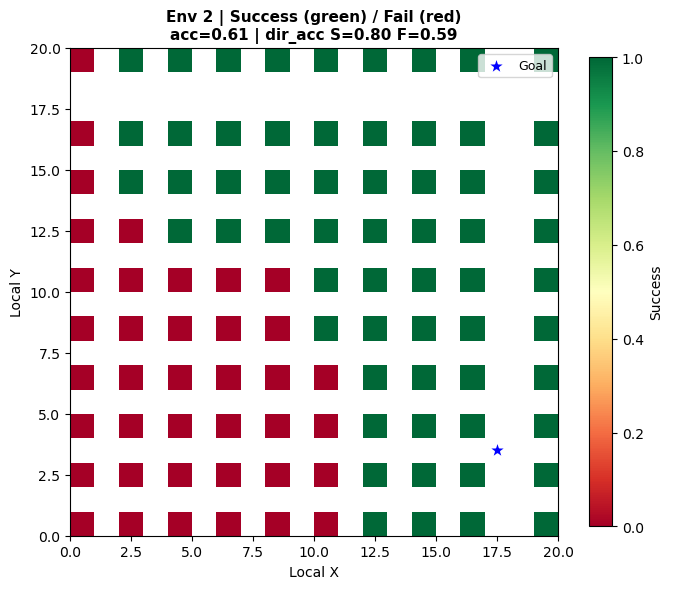

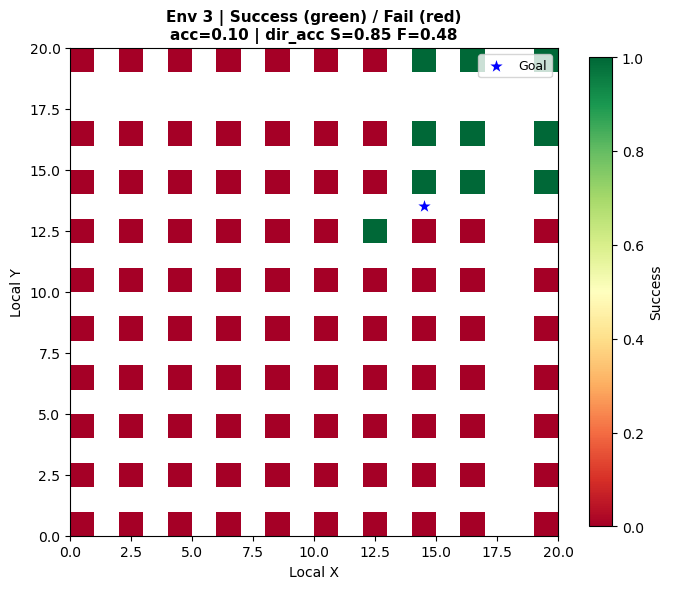

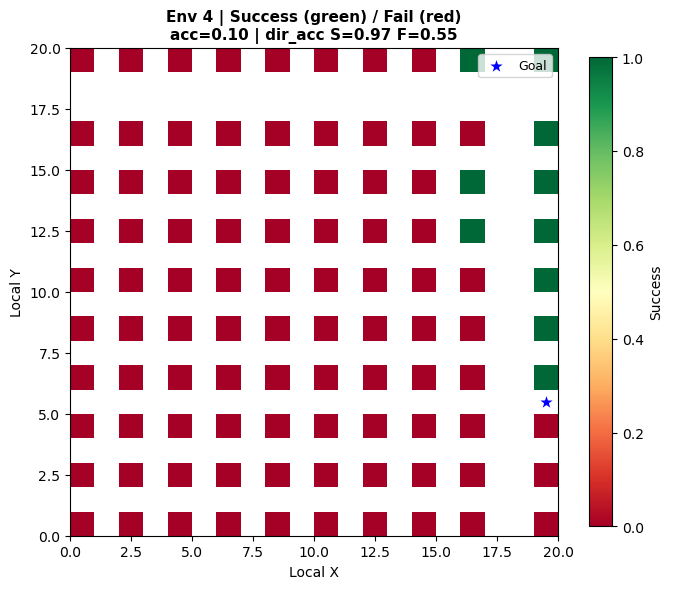

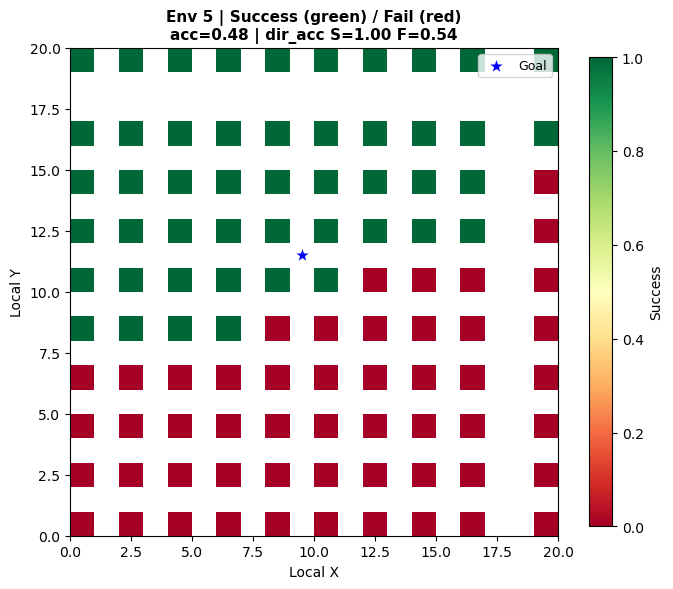

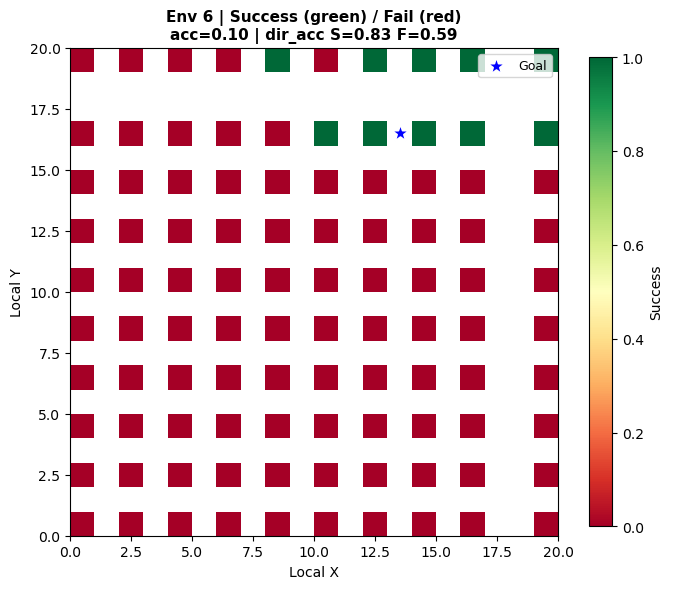

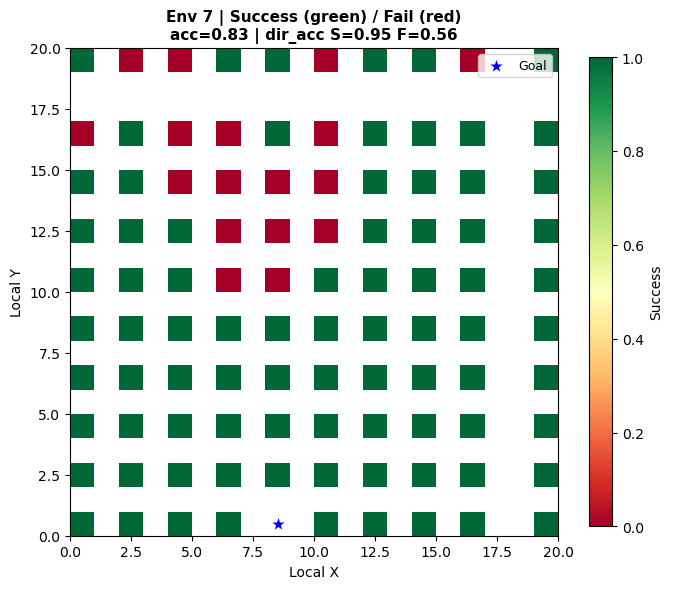

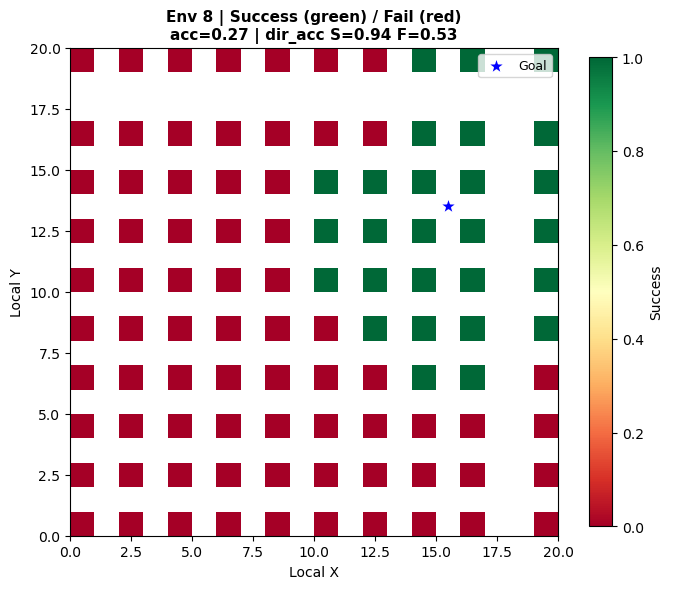

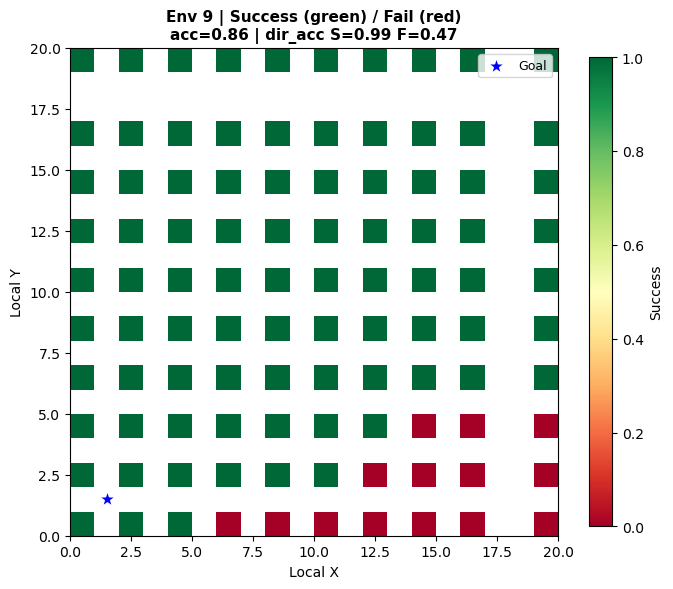

In [26]:
## ── Hopfield Navigation Diagnostic ──
# Tests navigation accuracy and efficiency across environments using continuous stepping.
# For each environment, samples starting positions and simulates continuous
# trajectories (normalize=True, scale=1, recompute W every step). Reports:
#   - accuracy: fraction of starts that reached within PLATFORM_RADIUS of goal
#   - mean steps for successful trajectories
#   - mean final euclidean distance to goal

N_EVAL_ENVS = 10           # Number of environments to test
EVAL_ENV_SIZE = 20         # Size of each environment patch
N_STARTS_PER_ENV = 100     # Starting positions sampled per environment
MAX_STEPS_MULT = 3         # max_steps = MAX_STEPS_MULT * env_size
EVAL_ALPHA = 0.6       # Hopfield recall alpha
EVAL_SCALE = 1.0           # Step scale (with normalize=True, each step is unit length * scale)
EVAL_NORMALIZE = True      # Normalize steps to unit length
EVAL_FLOOR = 0.0           # No floor needed when normalizing
EVAL_PLATFORM_RADIUS = 1.0 # Goal reached when within this distance
EVAL_RECOMPUTE_INTERVAL = 1
FIXED_ENVS = True          # If True, use a fixed seed for env/goal placement (reproducible across calls)

eval_seed = 42 if FIXED_ENVS else None
eval_rng = np.random.RandomState(eval_seed)

# --- Place environments ---
eval_used = []
eval_C_pairs = []
max_tries = 10_000
tries = 0
while len(eval_C_pairs) < N_EVAL_ENVS and tries < max_tries:
    x = eval_rng.randint(0, Npos - EVAL_ENV_SIZE + 1)
    y = eval_rng.randint(0, Npos - EVAL_ENV_SIZE + 1)
    if all(not overlaps(x, y, px, py, EVAL_ENV_SIZE, touch_ok=False) for (px, py) in eval_used):
        eval_used.append((x, y))
        eval_C_pairs.append((x, y))
    tries += 1

if len(eval_C_pairs) < N_EVAL_ENVS:
    print(f"WARNING: Could only place {len(eval_C_pairs)}/{N_EVAL_ENVS} non-overlapping envs")
    N_EVAL_ENVS = len(eval_C_pairs)

eval_env_indices = []
eval_goal_locations = []
eval_goal_states = []

for ei in range(N_EVAL_ENVS):
    C_X, C_Y = eval_C_pairs[ei]
    x, y = np.meshgrid(np.arange(EVAL_ENV_SIZE), np.arange(EVAL_ENV_SIZE), indexing='ij')
    env_indices = np.stack((C_X + x, C_Y + y), axis=-1)
    eval_env_indices.append(env_indices)

    flat_env = env_indices.reshape(-1, 2)
    goal_loc = flat_env[eval_rng.choice(len(flat_env))]
    eval_goal_states.append(Phi[:, goal_loc[0], goal_loc[1]])
    eval_goal_locations.append(goal_loc)

# --- Build Hopfield network for eval envs ---
eval_hop = Hopfield(num_units=embed_dim, beta=gain, device="cpu")
eval_Phi_mem = torch.stack(eval_goal_states).to(device)
eval_Phi_mem_encoded = encoder(eval_Phi_mem, gain=gain).detach().cpu()
for i in range(N_EVAL_ENVS):
    eval_hop.input_memory(eval_Phi_mem_encoded[i])

print(f"Placed {N_EVAL_ENVS} eval environments ({EVAL_ENV_SIZE}x{EVAL_ENV_SIZE}), stored {eval_hop.num_memories} goals in Hopfield")

# --- Simulate one trajectory (continuous) using eval_hop ---
def eval_simulate_continuous(env_idx, start_x, start_y):
    env_indices = eval_env_indices[env_idx]
    goal_loc = eval_goal_locations[env_idx]
    max_steps = MAX_STEPS_MULT * EVAL_ENV_SIZE

    min_x, max_x = 1, encoded_Phi.shape[0] - 2
    min_y, max_y = 1, encoded_Phi.shape[1] - 2

    start_loc = env_indices[start_x, start_y].astype(float)
    position = start_loc.copy()
    trajectory = [position.copy()]

    W, _ = compute_projection_matrix_at_pos(np.round(position).astype(int))
    steps_since_recompute = 0

    for step in range(max_steps):
        grid_pos = np.clip(np.round(position).astype(int), [min_x, min_y], [max_x, max_y])
        state = encoded_Phi[grid_pos[0], grid_pos[1]]
        current_np = state.numpy()

        next_state, _ = eval_hop.recall(state, steps=1, beta=gain, alpha=EVAL_ALPHA,
                                        use_tanh=True, normalize_each=True)

        if EVAL_RECOMPUTE_INTERVAL > 0 and steps_since_recompute >= EVAL_RECOMPUTE_INTERVAL:
            W, _ = compute_projection_matrix_at_pos(grid_pos)
            steps_since_recompute = 0

        (dx, dy), angle, mag = get_continuous_step(W, current_np, next_state.numpy(),
                                                    scale=EVAL_SCALE, normalize=EVAL_NORMALIZE,
                                                    floor=EVAL_FLOOR)
        steps_since_recompute += 1

        if mag < 1e-6:
            break

        new_position = position + np.array([dx, dy])
        new_position[0] = np.clip(new_position[0], min_x, max_x)
        new_position[1] = np.clip(new_position[1], min_y, max_y)

        if np.linalg.norm(new_position - position) < 1e-6:
            break

        position = new_position
        trajectory.append(position.copy())

        if np.linalg.norm(position - goal_loc) < EVAL_PLATFORM_RADIUS:
            break

    return np.array(trajectory)

# --- Run navigation from sampled starts ---
per_env_results = []
per_env_trajectories = []  # for visualization

for env_idx in range(N_EVAL_ENVS):
    env_indices = eval_env_indices[env_idx]
    goal_loc = eval_goal_locations[env_idx]
    C_X, C_Y = eval_C_pairs[env_idx]

    # Evenly spaced grid of starting positions
    n_per_side = int(np.ceil(np.sqrt(N_STARTS_PER_ENV)))
    sx_vals = np.linspace(0, EVAL_ENV_SIZE - 1, n_per_side).astype(int)
    sy_vals = np.linspace(0, EVAL_ENV_SIZE - 1, n_per_side).astype(int)
    goal_local = (goal_loc[0] - C_X, goal_loc[1] - C_Y)
    starts = [(sx, sy) for sx in sx_vals for sy in sy_vals if (sx, sy) != goal_local]

    successes = 0
    steps_list = []
    speed_list = []  # start_dist / steps for successes
    dist_at_end_success = []
    dist_at_end_fail = []
    trajectories = []
    dir_acc_success = []  # direction accuracy for successful trajectories
    dir_acc_fail = []     # direction accuracy for failed trajectories

    for (sx, sy) in starts:
        traj = eval_simulate_continuous(env_idx, sx, sy)
        trajectories.append(traj)

        start_pos = traj[0]
        start_dist = np.linalg.norm(start_pos - goal_loc)
        final_pos = traj[-1]
        final_dist = np.linalg.norm(final_pos - goal_loc)
        n_steps = len(traj) - 1

        # Direction accuracy: fraction of steps that reduce distance to goal
        if n_steps > 0:
            dists_along = np.linalg.norm(traj - goal_loc, axis=1)
            closer_steps = np.sum(dists_along[1:] < dists_along[:-1])
            da = closer_steps / n_steps
        else:
            da = float('nan')

        if final_dist < EVAL_PLATFORM_RADIUS:
            successes += 1
            steps_list.append(n_steps)
            speed_list.append(start_dist / n_steps if n_steps > 0 else float('inf'))
            dist_at_end_success.append(final_dist)
            if not np.isnan(da):
                dir_acc_success.append(da)
        else:
            dist_at_end_fail.append(final_dist)
            if not np.isnan(da):
                dir_acc_fail.append(da)

    accuracy = successes / len(starts)
    mean_steps = np.mean(steps_list) if steps_list else float('nan')
    mean_speed = np.mean(speed_list) if speed_list else float('nan')
    mean_dist_success = np.mean(dist_at_end_success) if dist_at_end_success else float('nan')
    mean_dist_fail = np.mean(dist_at_end_fail) if dist_at_end_fail else float('nan')
    mean_dir_acc_succ = np.mean(dir_acc_success) if dir_acc_success else float('nan')
    mean_dir_acc_fail = np.mean(dir_acc_fail) if dir_acc_fail else float('nan')

    per_env_results.append({
        'env_idx': env_idx,
        'C': eval_C_pairs[env_idx],
        'goal': tuple(goal_loc),
        'n_starts': len(starts),
        'accuracy': accuracy,
        'mean_steps': mean_steps,
        'mean_speed': mean_speed,
        'mean_dist_success': mean_dist_success,
        'mean_dist_fail': mean_dist_fail,
        'mean_dir_acc_succ': mean_dir_acc_succ,
        'mean_dir_acc_fail': mean_dir_acc_fail,
        'starts': starts,
        'trajectories_success': [i for i, t in enumerate(trajectories)
                                  if np.linalg.norm(t[-1] - goal_loc) < EVAL_PLATFORM_RADIUS],
    })
    per_env_trajectories.append(trajectories)

    print(f"  Env {env_idx:2d} | acc={accuracy:.2f} | "
          f"dir_acc_succ={mean_dir_acc_succ:.2f} | dir_acc_fail={mean_dir_acc_fail:.2f} | "
          f"mean_steps={mean_steps:5.1f} | speed={mean_speed:.3f} | "
          f"dist_succ={mean_dist_success:.2f} | dist_fail={mean_dist_fail:.2f}")

# --- Aggregate ---
accs = [r['accuracy'] for r in per_env_results]
dir_accs_succ = [r['mean_dir_acc_succ'] for r in per_env_results if not np.isnan(r['mean_dir_acc_succ'])]
dir_accs_fail = [r['mean_dir_acc_fail'] for r in per_env_results if not np.isnan(r['mean_dir_acc_fail'])]
steps_all = [r['mean_steps'] for r in per_env_results if not np.isnan(r['mean_steps'])]
speeds_all = [r['mean_speed'] for r in per_env_results if not np.isnan(r['mean_speed'])]
dists_succ = [r['mean_dist_success'] for r in per_env_results if not np.isnan(r['mean_dist_success'])]
dists_fail = [r['mean_dist_fail'] for r in per_env_results if not np.isnan(r['mean_dist_fail'])]

print(f"\n{'='*60}")
print(f"AGGREGATE ({N_EVAL_ENVS} envs, {N_STARTS_PER_ENV} starts each)")
print(f"  accuracy:        {np.mean(accs):.3f}  (std {np.std(accs):.3f})")
print(f"  dir_acc_succ:    {np.mean(dir_accs_succ):.3f}  (std {np.std(dir_accs_succ):.3f})" if dir_accs_succ else "  dir_acc_succ:    N/A (no successes)")
print(f"  dir_acc_fail:    {np.mean(dir_accs_fail):.3f}  (std {np.std(dir_accs_fail):.3f})" if dir_accs_fail else "  dir_acc_fail:    N/A (all succeeded)")
print(f"  mean_steps:      {np.mean(steps_all):.1f}  (std {np.std(steps_all):.1f})" if steps_all else "  mean_steps:      N/A (no successes)")
print(f"  speed:           {np.mean(speeds_all):.3f}  (std {np.std(speeds_all):.3f})" if speeds_all else "  speed:           N/A (no successes)")
print(f"  dist_success:    {np.mean(dists_succ):.2f}  (std {np.std(dists_succ):.2f})" if dists_succ else "  dist_success:    N/A")
print(f"  dist_fail:       {np.mean(dists_fail):.2f}  (std {np.std(dists_fail):.2f})" if dists_fail else "  dist_fail:       N/A (all succeeded)")
print(f"{'='*60}")

# --- Visualize all trajectories per environment ---
for env_idx in range(N_EVAL_ENVS):
    env_indices = eval_env_indices[env_idx]
    goal_loc = eval_goal_locations[env_idx]
    C_X, C_Y = eval_C_pairs[env_idx]
    trajectories = per_env_trajectories[env_idx]
    r = per_env_results[env_idx]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Environment boundary
    env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), EVAL_ENV_SIZE, EVAL_ENV_SIZE,
                                fill=False, edgecolor='steelblue',
                                linewidth=2, linestyle='--')
    ax.add_patch(env_bounds)

    # Faint grid
    pos = env_indices.reshape(-1, 2)
    ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=10, alpha=0.4, zorder=1)

    # Color trajectories
    cmap = plt.cm.turbo
    norm_c = plt.Normalize(0, len(trajectories) - 1)

    for idx, traj in enumerate(trajectories):
        color = cmap(norm_c(idx))
        ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=0.8, alpha=0.6, zorder=2)
        ax.scatter(traj[0, 0], traj[0, 1], c=[color], s=15, marker='o',
                   edgecolors='k', linewidths=0.3, zorder=5)
        ax.scatter(traj[-1, 0], traj[-1, 1], c=[color], s=10, marker='s',
                   edgecolors='k', linewidths=0.2, alpha=0.7, zorder=5)

    # Goal
    goal_circle = plt.Circle((goal_loc[0], goal_loc[1]), EVAL_PLATFORM_RADIUS,
                              fill=True, facecolor='crimson', alpha=0.4,
                              edgecolor='darkred', linewidth=2, zorder=6)
    ax.add_patch(goal_circle)

    pad = 3
    ax.set_xlim(C_X - pad, C_X + EVAL_ENV_SIZE + pad - 1)
    ax.set_ylim(C_Y - pad, C_Y + EVAL_ENV_SIZE + pad - 1)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(
        f'Env {env_idx} | acc={r["accuracy"]:.2f} | '
        f'mean_steps={r["mean_steps"]:.1f} | speed={r["mean_speed"]:.3f}',
        fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=6, label='Start'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=6, label='End'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
               alpha=0.4, markeredgecolor='darkred', markersize=8,
               label=f'Goal (r={EVAL_PLATFORM_RADIUS})'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

# --- Success/Failure heatmap per environment ---
for env_idx in range(N_EVAL_ENVS):
    r = per_env_results[env_idx]
    goal_loc = eval_goal_locations[env_idx]
    C_X, C_Y = eval_C_pairs[env_idx]
    trajectories = per_env_trajectories[env_idx]
    starts = r['starts']
    success_set = set(r['trajectories_success'])

    # Build heatmap: 1=success, 0=fail, nan=not tested
    heatmap = np.full((EVAL_ENV_SIZE, EVAL_ENV_SIZE), np.nan)
    for i, (sx, sy) in enumerate(starts):
        heatmap[sx, sy] = 1.0 if i in success_set else 0.0

    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(heatmap.T, origin='lower', cmap='RdYlGn', vmin=0, vmax=1,
                   extent=[0, EVAL_ENV_SIZE, 0, EVAL_ENV_SIZE])

    # Goal marker
    gx_local = goal_loc[0] - C_X
    gy_local = goal_loc[1] - C_Y
    ax.scatter(gx_local + 0.5, gy_local + 0.5, s=200, c='blue', marker='*',
               edgecolors='white', linewidths=1.5, zorder=6, label='Goal')

    ax.set_xlabel('Local X')
    ax.set_ylabel('Local Y')
    ax.set_title(f'Env {env_idx} | Success (green) / Fail (red)\n'
                 f'acc={r["accuracy"]:.2f} | dir_acc S={r["mean_dir_acc_succ"]:.2f} F={r["mean_dir_acc_fail"]:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Success')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
save_encoder(encoder, config, "lambda_11_12_13_full_wNpos=50.pt") #good hopfield, see if can get continuous to work

Saved encoder to /home/jackking/cls/encoders/lambda_11_12_13_full_wNpos=50.pt
